# Charging Analysis v2 - 基于本地轨迹数据的充电行为分析

本 notebook 基于已下载到本地的车辆轨迹数据（parquet格式），重新实现充电事件检测、排队模拟、能耗和SOC计算等分析流程。

## 主要改进
- 直接读取本地 parquet 轨迹数据（按 taxiid 分目录存储）
- 基于站点半径 + 连续停留时间的充电检测逻辑
- 考虑数据缺失情况下的能耗计算
- 完整的排队模拟和SOC轨迹追踪


## 1. 导入库和工具函数


In [1]:
import cudf
import cupy as cp
import pandas as pd
import numpy as np
import os
from pathlib import Path
from scipy.spatial import cKDTree
from heapq import heappush, heappop
import pyarrow.parquet as pq
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
import pickle


# 配置日志
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")


In [2]:
# Haversine距离计算（GPU加速）
def haversine_distance_gpu(lon1, lat1, lon2, lat2):
    """
    计算两点间的大圆距离（米），使用cupy进行GPU加速
    """

    # lon1 = cp.asarray(lon1.values if hasattr(lon1, 'values') else lon1)
    # lat1 = cp.asarray(lat1.values if hasattr(lat1, 'values') else lat1)
    # lon2 = cp.asarray(lon2.values if hasattr(lon2, 'values') else lon2)
    # lat2 = cp.asarray(lat2.values if hasattr(lat2, 'values') else lat2)

    lon1_rad = cp.radians(lon1.astype(cp.float64))
    lat1_rad = cp.radians(lat1.astype(cp.float64))
    lon2_rad = cp.radians(lon2.astype(cp.float64))
    lat2_rad = cp.radians(lat2.astype(cp.float64))

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    a = cp.sin(dlat / 2)**2 + cp.cos(lat1_rad) * cp.cos(lat2_rad) * cp.sin(dlon / 2)**2
    c = 2 * cp.arcsin(cp.sqrt(a))
    R = 6371000  # 地球半径（米）
    return c * R


## 2. 参数设置


In [3]:
# ========== 充电检测参数 ==========
R_STATION = 200          # 充电站匹配半径（米）
T_STAY = 600             # 最小停留时间（秒），10分钟
T_GAP = 300              # 同一站点内连续点的最大时间间隔（秒），超过则断开
PASSENGER_THR = 0        # 空载判断：passenger == 0

# ========== 能耗和电池参数 ==========
CAP_KWH = 80             # 电池容量（kWh）
CONS_KWH_PER_KM = 0.15   # 能耗率（kWh/km）
AVG_SPEED_KMH = 20       # 平均速度（km/h），用于缺数据时的估算
CHG_EFFICIENCY = 1.0     # 充电效率

# ========== 数据缺失处理 ==========
MAX_GAP_SECONDS = 600   # 最大允许数据缺失时间（秒）10分钟，超过则不计能耗,视为断开GPS

# ========== 路径设置 ==========
TRACKS_DIR = '../data/taxi_trajectories.parquet'  # 轨迹数据根目录
STATION_CSV = 'station_information.csv'           # 充电站信息
PILE_CSV = 'pile_rated_power.csv'                 # 充电桩功率信息

# ========== 输出文件 ==========
OUTPUT_DIR = 'output_v3'
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHARGING_EVENTS_FILE = f'{OUTPUT_DIR}/charging_events_p.parquet'
CHAR_QUEUE_FILE = f'{OUTPUT_DIR}/char_queue_p.parquet'
ENERGY_GAP_FILE = f'{OUTPUT_DIR}/energy_gap_p.parquet'
BATTERY_TRACE_FILE = f'{OUTPUT_DIR}/battery_trace_p.parquet'
PRIVATE_GAP_FILE = f'{OUTPUT_DIR}/private_gap_charging_events_p.parquet'
PUBLIC_GAP_FILE = f'{OUTPUT_DIR}/public_gap_charging_events_p.parquet'  # 从gap检测到的公共充电


# ========== 并行处理参数 ==========
MAX_WORKERS = 10          # 并行处理的线程数


## 3. 充电站数据预处理


In [4]:
# 读取充电站和充电桩数据
stations_df = pd.read_csv(STATION_CSV, dtype={'station_id': np.int32})
piles_df = pd.read_csv(PILE_CSV, dtype={'station_id': np.int32, 'pile_id': np.int32})

# 过滤有效充电桩（功率在合理范围内）
max_power = 60
valid_piles_df = piles_df[(piles_df['power'] > 0) & (piles_df['power'] <= max_power)].copy()

# 统计每个站的充电桩信息
stat_pile_df = valid_piles_df.groupby('station_id').agg(
    num_piles=('power', 'count'),
    avg_power=('power', 'mean'),
    max_power=('power', 'max'),
    min_power=('power', 'min')
).reset_index()

# 合并站点信息和桩统计
stations_df = stations_df.merge(stat_pile_df, on='station_id', how='inner')

# 只保留有充电桩的站点
stations_df = stations_df[stations_df['num_piles'] > 0].copy()

print(f"加载了 {len(stations_df)} 个有效充电站")
print(f"总充电桩数: {stations_df['num_piles'].sum()}")
print(f"平均每站桩数: {stations_df['num_piles'].mean():.1f}")


加载了 1478 个有效充电站
总充电桩数: 19988
平均每站桩数: 13.5


In [5]:
# 构建KDTree用于快速最近邻查询（CPU）
station_coords = stations_df[['longitude', 'latitude']].to_numpy()
station_tree = cKDTree(station_coords)
station_id_lookup = stations_df['station_id'].to_numpy()

print("充电站KDTree构建完成")


充电站KDTree构建完成


# GPS中断

In [6]:

# ========= 自行修改的路径与参数 =========
TRACKS_DIR = '../data/taxi_trajectories.parquet'  # parquet 根目录
MAX_WORKERS = 8                                    # 并行线程数
GAP_THRESHOLD_S = 1800                             # 30 分钟
# =====================================

def haversine_np(lon1, lat1, lon2, lat2):
    """向量化 haversine 计算（米）"""
    R = 6371000
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

def find_gaps_for_taxi(taxiid: str) -> pd.DataFrame:
    """返回该车所有 >30min 中断的前后点信息"""
    taxi_path = Path(TRACKS_DIR) / f'taxiid={taxiid}'
    files = list(taxi_path.glob('*.parquet'))
    if not files:
        return pd.DataFrame()

    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    if df.empty:
        return pd.DataFrame()

    df = df.sort_values('time').reset_index(drop=True)
    df['prev_time'] = df['time'].shift()
    df['gap_s'] = (df['time'] - df['prev_time']).dt.total_seconds()
    gaps = df[df['gap_s'] > GAP_THRESHOLD_S].copy()

    if gaps.empty:
        return pd.DataFrame()

    prev_rows = df.loc[gaps.index - 1].reset_index(drop=True)
    gaps = gaps.reset_index(drop=True)

    out = pd.DataFrame({
        'taxiid': taxiid,
        'prev_time': prev_rows['time'],
        'next_time': gaps['time'],
        'gap_s': gaps['gap_s'],
        'prev_lon': prev_rows['lon'],
        'prev_lat': prev_rows['lat'],
        'next_lon': gaps['lon'],
        'next_lat': gaps['lat']
    })
    out['dist_m'] = haversine_np(
        out['prev_lon'], out['prev_lat'],
        out['next_lon'], out['next_lat']
    )
    return out

# ==== 主程序：并行遍历所有车辆 ====
def get_all_taxiids(tracks_dir):
    return sorted(p.name.replace('taxiid=', '')
                  for p in Path(tracks_dir).iterdir()
                  if p.is_dir() and p.name.startswith('taxiid='))

all_taxiids = get_all_taxiids(TRACKS_DIR)
results = []

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as exe:
    futures = {exe.submit(find_gaps_for_taxi, tid): tid for tid in all_taxiids}
    for f in tqdm(as_completed(futures), total=len(futures), desc='扫描轨迹中断'):
        df_gap = f.result()
        if not df_gap.empty:
            results.append(df_gap)

gap_events = pd.concat(results, ignore_index=True) if results else pd.DataFrame()
print(f'共找到 {len(gap_events)} 个中断事件，涉及 {gap_events.taxiid.nunique()} 辆车')
gap_events.head()

扫描轨迹中断: 100%|██████████| 19495/19495 [05:39<00:00, 57.51it/s] 


共找到 375468 个中断事件，涉及 19268 辆车


,taxiid,prev_time,next_time,gap_s,prev_lon,prev_lat,next_lon,next_lat,dist_m
0,UUUB0C1Q1,2020-01-01 04:20:44,2020-01-01 06:07:39,6415.0,114.105286,22.543913,114.105255,22.543707,22.956581
1,UUUB0C1Q1,2020-01-01 12:36:39,2020-01-01 14:00:18,5019.0,114.057541,22.567093,114.057449,22.567095,9.820447
2,UUUB0C1Q1,2020-01-02 03:50:41,2020-01-02 05:26:51,5770.0,113.999374,22.536880,113.999359,22.536528,39.328243
3,UUUB0C1Q1,2020-01-02 11:17:11,2020-01-02 12:21:06,3835.0,114.057449,22.567051,114.055862,22.566824,164.656601
4,UUUB0C1Q1,2020-01-02 15:53:04,2020-01-02 17:42:48,6584.0,114.129707,22.638012,114.129639,22.637953,9.529450


In [11]:
gap_events2 = gap_events[gap_events['gap_s'] > 3600]

In [7]:


# ------------------------------------
# gap_events DataFrame 已包含下列字段：
# taxiid, prev_lon, prev_lat, ...  等
# ------------------------------------

EARTH_RADIUS_M = 6371000
EPS_METERS = 500           # 距离阈值 500 m
# DBSCAN 需要弧度制，且 eps 以“弧度”表达
EPS_RADIANS = EPS_METERS / EARTH_RADIUS_M
MIN_SAMPLES = 1            # 至少 1 个点即可形成簇

def cluster_points(df_one: pd.DataFrame) -> int:
    """返回该车聚集点（簇）数量"""
    if len(df_one) == 0:
        return 0
    coords_rad = np.radians(df_one[['prev_lat', 'prev_lon']].values)
    model = DBSCAN(eps=EPS_RADIANS,
                   min_samples=MIN_SAMPLES,
                   algorithm='ball_tree',
                   metric='haversine')
    labels = model.fit_predict(coords_rad)
    return pd.Series(labels).nunique()

# 计算每辆车的簇数量
cluster_counts = (gap_events
                  .groupby('taxiid')
                  .apply(cluster_points)
                  .rename('n_clusters')
                  .reset_index())

# 统计簇数量分布
distribution = (cluster_counts['n_clusters']
                .value_counts()
                .sort_index()
                .rename_axis('clusters_per_taxi')
                .reset_index(name='num_taxis'))

print("每辆车聚集点数量统计表：")
print(cluster_counts.head())

print("\n聚集点数量分布：")
print(distribution)

每辆车聚集点数量统计表：
      taxiid  n_clusters
0  UUUB0C0M7           5
1  UUUB0C0P3           2
2  UUUB0C0P5           7
3  UUUB0C0Q9          11
4  UUUB0C1P1           4

聚集点数量分布：
    clusters_per_taxi  num_taxis
0                   1        523
1                   2       1167
2                   3       1805
3                   4       2454
4                   5       2623
5                   6       2528
6                   7       2239
7                   8       1890
8                   9       1414
9                  10       1008
10                 11        681
11                 12        416
12                 13        236
13                 14        128
14                 15         81
15                 16         26
16                 17         17
17                 18         14
18                 19          6
19                 20          2
20                 21          1
21                 22          1
22                 24          2
23                 27          1
24

/tmp/ipykernel_957107/145976378.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(cluster_points)


Gap 时长 (小时) 描述：
count    236856.000000
mean          3.032231
std           3.556148
min           1.000278
25%           1.271111
50%           1.600833
75%           2.999444
max         143.913056
Name: gap_hours, dtype: float64

Gap 时长分布 (0.5h bin)：
gap_hours
[0.0, 0.5)         0
[0.5, 1.0)         0
[1.0, 1.5)    103579
[1.5, 2.0)     47401
[2.0, 2.5)     16829
[2.5, 3.0)      9840
[3.0, 3.5)      6880
[3.5, 4.0)      5099
[4.0, 4.5)      4213
[4.5, 5.0)      3520
dtype: int64

按小时统计 gap 发生次数：
start_hour
0      8167
1     13290
2     20411
3     25654
4     26036
5     21289
6     12010
7      6569
8      3684
9      3127
10     3290
11     4933
12     6607
13     5496
14     6517
15     9500
16    15109
17    13444
18     8602
19     6103
20     4744
21     4013
22     3826
23     4435
Name: count, dtype: int64

按星期几统计 gap 发生次数 (0=周一)：
weekday
0    33636
1    31173
2    34894
3    34129
4    32847
5    34247
6    35930
Name: count, dtype: int64


/tmp/ipykernel_957107/1904566657.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dur_dist = df.groupby(pd.cut(df['gap_hours'], bins, right=False)).size()
/home/lxhep/miniconda3/envs/rapids-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21457 (\N{CJK UNIFIED IDEOGRAPH-53D1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lxhep/miniconda3/envs/rapids-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lxhep/miniconda3/envs/rapids-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) De

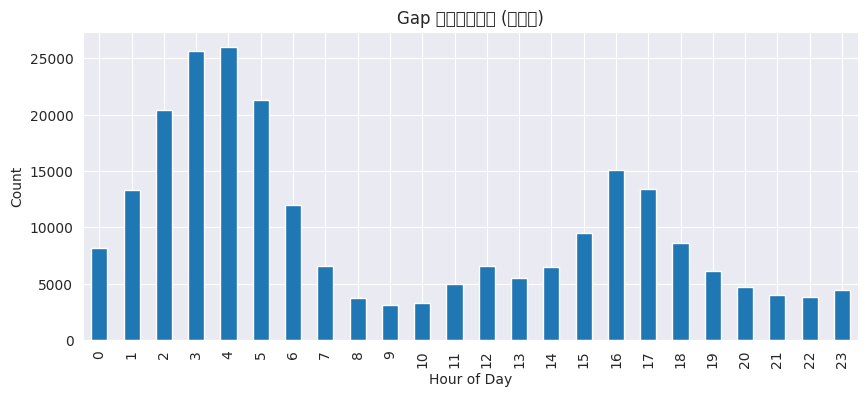

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# gap_events 已包含 prev_time、gap_s 等字段
df = gap_events2.copy()

# ================= 1. gap 时长分布 =================
df['gap_hours'] = df['gap_s'] / 3600            # 转小时

# a) 描述性统计
print("Gap 时长 (小时) 描述：")
print(df['gap_hours'].describe())

# b) 按 0.5 小时分箱计数
bins = np.arange(0, df['gap_hours'].max() + 0.5, 0.5)
dur_dist = df.groupby(pd.cut(df['gap_hours'], bins, right=False)).size()
print("\nGap 时长分布 (0.5h bin)：")
print(dur_dist.head(10))       # 视需求打印更多

# ================= 2. 发生时间分布 =================
# 以“中断开始时刻” prev_time 的小时进行统计
df['start_hour'] = df['prev_time'].dt.hour
hour_dist = df['start_hour'].value_counts().sort_index()
print("\n按小时统计 gap 发生次数：")
print(hour_dist)

# 若需要按星期几：
df['weekday'] = df['prev_time'].dt.dayofweek      # 0=周一
weekday_dist = df['weekday'].value_counts().sort_index()
print("\n按星期几统计 gap 发生次数 (0=周一)：")
print(weekday_dist)

# ================= 3. 快速可视化（可选） ================
plt.figure(figsize=(10,4))
hour_dist.plot(kind='bar')
plt.title('Gap 发生时间分布 (按小时)')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.show()

Using columns: prev_lon (longitude), prev_lat (latitude), taxiid (taxiid)
Processing 236137 private charging events from 19126 vehicles

Stop Points Statistics per Vehicle

Total vehicles: 19126
Total private charging events: 236137

Stop Points Distribution:
  Mean: 3.74 points/vehicle
  Median: 3.00 points/vehicle
  Min: 1 points
  Max: 33 points
  Std: 2.04

Distribution by number of stop points:
Stop Points     Vehicles        Percentage     
---------------------------------------------
1               2279            11.92%
2               3620            18.93%
3               3896            20.37%
4               3361            17.57%
5               2482            12.98%
6               1635            8.55%
7               951             4.97%
8               507             2.65%
9               219             1.15%
10              94              0.49%
11              44              0.23%
12              13              0.07%
13              10              0.05%
14  

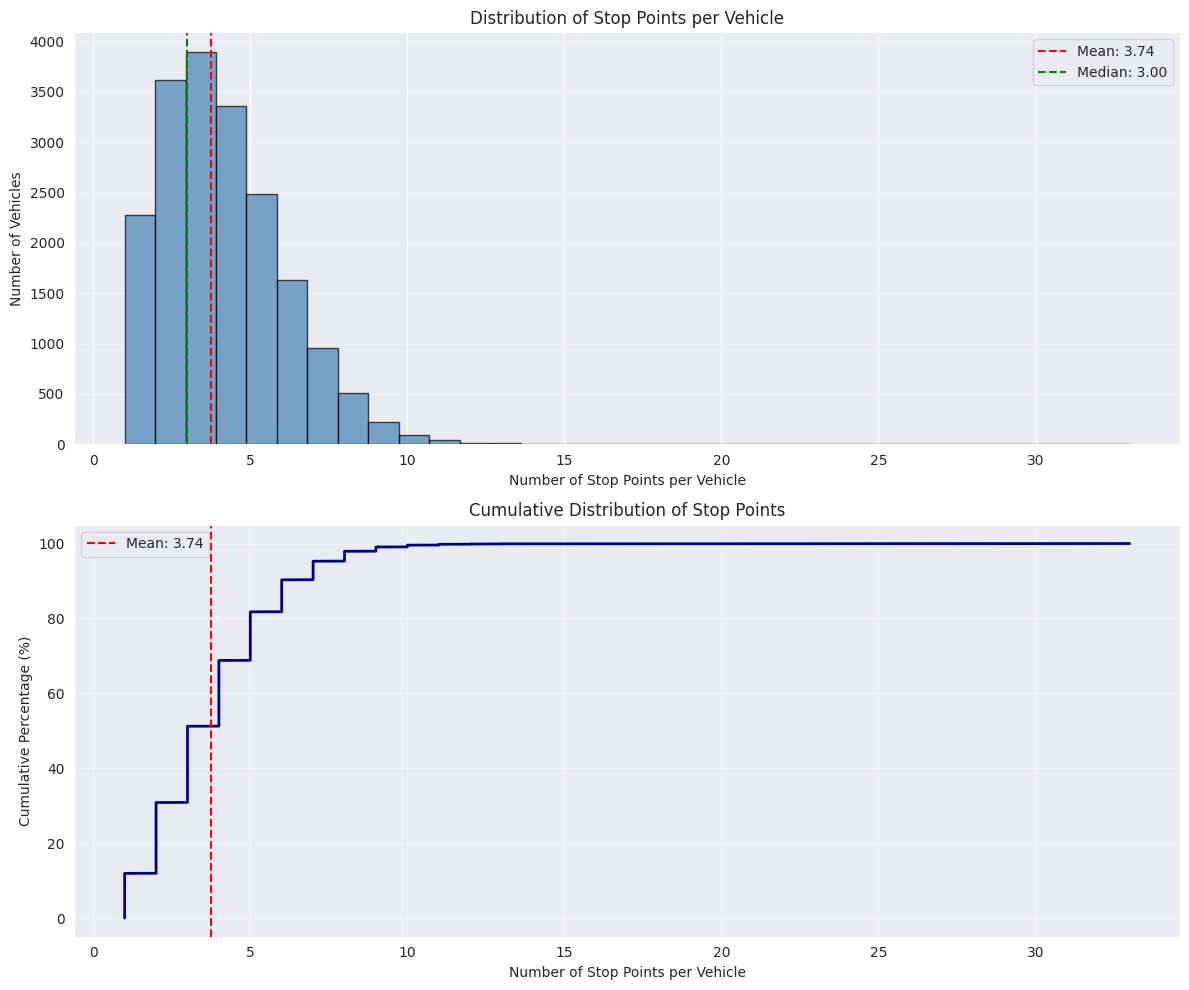


Results saved to: vehicle_stop_points_count.csv
Distribution statistics saved to: stop_points_distribution.txt


Additional Analysis:
  Vehicles with 1 stop point: 2279 (11.92%)
  Vehicles with 2-3 stop points: 7516 (39.30%)
  Vehicles with 4-8 stop points: 8936 (46.72%)
  Vehicles with >8 stop points: 395 (2.07%)


In [13]:

if not private_charges_df.empty:
    # 确定位置列和车辆ID列
    lon_col = None
    lat_col = None
    taxiid_col = None

    for col in private_charges_df.columns:
        if 'pre_lon' in col.lower() or ('lon' in col.lower() and 'pre' in col.lower()):
            lon_col = col
        if 'pre_lat' in col.lower() or ('lat' in col.lower() and 'pre' in col.lower()):
            lat_col = col
        if 'taxiid' in col.lower() or 'taxi_id' in col.lower():
            taxiid_col = col

    if lon_col is None:
        for col in private_charges_df.columns:
            if 'lon' in col.lower():
                lon_col = col
                break
    if lat_col is None:
        for col in private_charges_df.columns:
            if 'lat' in col.lower():
                lat_col = col
                break

    if lon_col is None or lat_col is None or taxiid_col is None:
        print("Error: Cannot find required columns")
        print("Available columns:", list(private_charges_df.columns))
    else:
        print(f"Using columns: {lon_col} (longitude), {lat_col} (latitude), {taxiid_col} (taxiid)")

        # 过滤有效数据
        valid_df = private_charges_df.dropna(subset=[lon_col, lat_col, taxiid_col]).copy()
        valid_df = valid_df[
            (valid_df[lon_col] >= 113) & (valid_df[lon_col] <= 115) &
            (valid_df[lat_col] >= 22) & (valid_df[lat_col] <= 23)
        ]

        if len(valid_df) == 0:
            print("Error: No valid data found")
        else:
            print(f"Processing {len(valid_df)} private charging events from {valid_df[taxiid_col].nunique()} vehicles")

            # ========== 2. 对每辆车进行位置聚类 ==========
            def haversine_distance(lon1, lat1, lon2, lat2):
                """计算两点间的大圆距离（米）"""
                R = 6371000  # 地球半径（米）
                lon1_rad = np.radians(lon1)
                lat1_rad = np.radians(lat1)
                lon2_rad = np.radians(lon2)
                lat2_rad = np.radians(lat2)

                dlon = lon2_rad - lon1_rad
                dlat = lat2_rad - lat1_rad

                a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
                c = 2 * np.arcsin(np.sqrt(a))

                return R * c

            # 自定义距离函数用于DBSCAN（将度转换为米）
            def custom_distance_matrix(coords):
                """计算坐标之间的距离矩阵（米）"""
                n = len(coords)
                distances = np.zeros((n, n))
                for i in range(n):
                    for j in range(i+1, n):
                        dist = haversine_distance(
                            coords[i, 0], coords[i, 1],
                            coords[j, 0], coords[j, 1]
                        )
                        distances[i, j] = dist
                        distances[j, i] = dist
                return distances

            # 对每辆车进行聚类
            vehicle_stop_points = []

            for taxiid, group in valid_df.groupby(taxiid_col):
                coords = group[[lon_col, lat_col]].to_numpy()

                if len(coords) < 2:

                    # 只有一个点，算作1个停留点
                    vehicle_stop_points.append({
                        'taxiid': taxiid,
                        'n_stop_points': 1,
                        'n_events': len(coords)
                    })
                    continue

                # 计算距离矩阵（米）
                dist_matrix = custom_distance_matrix(coords)

                # 使用DBSCAN，eps=200米，min_samples=1（每个点都可以是一个聚类）
                # 注意：DBSCAN需要距离矩阵，我们使用precomputed
                from sklearn.cluster import DBSCAN

                # 由于DBSCAN的precomputed需要对称矩阵，我们直接使用距离矩阵
                dbscan = DBSCAN(eps=500, min_samples=1, metric='precomputed')
                labels = dbscan.fit_predict(dist_matrix)

                # 统计聚类数量（排除噪声点，但这里min_samples=1所以没有噪声）
                n_clusters = len(set(labels))

                vehicle_stop_points.append({
                    'taxiid': taxiid,
                    'n_stop_points': n_clusters,
                    'n_events': len(coords)
                })

            # 转换为DataFrame
            stop_points_df = pd.DataFrame(vehicle_stop_points)

            # ========== 3. 统计分布 ==========
            print("\n" + "=" * 60)
            print("Stop Points Statistics per Vehicle")
            print("=" * 60)

            print(f"\nTotal vehicles: {len(stop_points_df)}")
            print(f"Total private charging events: {stop_points_df['n_events'].sum()}")
            print(f"\nStop Points Distribution:")
            print(f"  Mean: {stop_points_df['n_stop_points'].mean():.2f} points/vehicle")
            print(f"  Median: {stop_points_df['n_stop_points'].median():.2f} points/vehicle")
            print(f"  Min: {stop_points_df['n_stop_points'].min()} points")
            print(f"  Max: {stop_points_df['n_stop_points'].max()} points")
            print(f"  Std: {stop_points_df['n_stop_points'].std():.2f}")

            # 统计不同停留点数量的车辆数
            stop_points_dist = stop_points_df['n_stop_points'].value_counts().sort_index()
            print(f"\nDistribution by number of stop points:")
            print(f"{'Stop Points':<15} {'Vehicles':<15} {'Percentage':<15}")
            print("-" * 45)
            for n_points, count in stop_points_dist.items():
                pct = count / len(stop_points_df) * 100
                print(f"{n_points:<15} {count:<15} {pct:.2f}%")

            # ========== 4. 可视化分布 ==========
            fig, axes = plt.subplots(2, 1, figsize=(12, 10))

            # 4.1 直方图
            axes[0].hist(stop_points_df['n_stop_points'], bins=min(50, stop_points_df['n_stop_points'].max()),
                        edgecolor='black', alpha=0.7, color='steelblue')
            axes[0].axvline(stop_points_df['n_stop_points'].mean(), color='red', linestyle='--',
                           label=f'Mean: {stop_points_df["n_stop_points"].mean():.2f}')
            axes[0].axvline(stop_points_df['n_stop_points'].median(), color='green', linestyle='--',
                           label=f'Median: {stop_points_df["n_stop_points"].median():.2f}')
            axes[0].set_xlabel('Number of Stop Points per Vehicle')
            axes[0].set_ylabel('Number of Vehicles')
            axes[0].set_title('Distribution of Stop Points per Vehicle')
            axes[0].legend()
            axes[0].grid(axis='y', alpha=0.3)

            # 4.2 累积分布
            sorted_points = np.sort(stop_points_df['n_stop_points'])
            cumulative = np.arange(1, len(sorted_points) + 1) / len(sorted_points) * 100
            axes[1].plot(sorted_points, cumulative, linewidth=2, color='darkblue')
            axes[1].axvline(stop_points_df['n_stop_points'].mean(), color='red', linestyle='--',
                           label=f'Mean: {stop_points_df["n_stop_points"].mean():.2f}')
            axes[1].set_xlabel('Number of Stop Points per Vehicle')
            axes[1].set_ylabel('Cumulative Percentage (%)')
            axes[1].set_title('Cumulative Distribution of Stop Points')
            axes[1].grid(True, alpha=0.3)
            axes[1].legend()

            plt.tight_layout()
            plt.show()

            # ========== 5. 保存结果 ==========
            stop_points_df.to_csv('vehicle_stop_points_count.csv', index=False)
            print(f"\nResults saved to: vehicle_stop_points_count.csv")

            # 保存分布统计
            with open('stop_points_distribution.txt', 'w') as f:
                f.write("Stop Points Distribution per Vehicle\n")
                f.write("=" * 60 + "\n\n")
                f.write(f"Total vehicles: {len(stop_points_df)}\n")
                f.write(f"Mean stop points: {stop_points_df['n_stop_points'].mean():.2f}\n")
                f.write(f"Median stop points: {stop_points_df['n_stop_points'].median():.2f}\n")
                f.write(f"Min: {stop_points_df['n_stop_points'].min()}\n")
                f.write(f"Max: {stop_points_df['n_stop_points'].max()}\n\n")
                f.write("Distribution:\n")
                for n_points, count in stop_points_dist.items():
                    pct = count / len(stop_points_df) * 100
                    f.write(f"  {n_points} points: {count} vehicles ({pct:.2f}%)\n")

            print(f"Distribution statistics saved to: stop_points_distribution.txt")

            print("\n" + "=" * 60)

            # ========== 6. 额外分析：停留点数量与事件数的关系 ==========
            print("\nAdditional Analysis:")
            print(f"  Vehicles with 1 stop point: {(stop_points_df['n_stop_points'] == 1).sum()} "
                  f"({(stop_points_df['n_stop_points'] == 1).sum()/len(stop_points_df)*100:.2f}%)")
            print(f"  Vehicles with 2-3 stop points: {((stop_points_df['n_stop_points'] >= 2) & (stop_points_df['n_stop_points'] <= 3)).sum()} "
                  f"({((stop_points_df['n_stop_points'] >= 2) & (stop_points_df['n_stop_points'] <= 3)).sum()/len(stop_points_df)*100:.2f}%)")
            print(f"  Vehicles with 4-8 stop points: {((stop_points_df['n_stop_points'] >= 4) & (stop_points_df['n_stop_points'] <= 8)).sum()} "
                  f"({((stop_points_df['n_stop_points'] >=4) & (stop_points_df['n_stop_points'] <= 8)).sum()/len(stop_points_df)*100:.2f}%)")
            print(f"  Vehicles with >8 stop points: {(stop_points_df['n_stop_points'] > 8).sum()} "
                  f"({(stop_points_df['n_stop_points'] > 8).sum()/len(stop_points_df)*100:.2f}%)")

            print("=" * 60)

In [15]:
import pandas as pd

# gap_events DataFrame 已包含 prev_time, taxiid, gap_s ...

# 1) gap 覆盖的天数
days_covered = gap_events2['prev_time'].dt.normalize().nunique()
print(f"Gap 事件共覆盖 {days_covered} 天")

# 2) 每辆车的 GPS 中断次数
per_taxi_counts = (gap_events2.groupby('taxiid')
                              .size()
                              .rename('n_gaps')
                              .reset_index())

print("\n每辆车中断次数（前 10 行示例）：")
print(per_taxi_counts.head(10))

# 3) 中断次数在车群中的分布
count_dist = (per_taxi_counts['n_gaps']
              .value_counts()
              .sort_index()
              .rename_axis('gaps_per_taxi')
              .reset_index(name='num_taxis'))

print("\n各车辆中断次数分布：")
print(count_dist)

Gap 事件共覆盖 7 天

每辆车中断次数（前 10 行示例）：
      taxiid  n_gaps
0  UUUB0C0M7      13
1  UUUB0C0P3      14
2  UUUB0C0P5      12
3  UUUB0C0Q9      18
4  UUUB0C1P1      14
5  UUUB0C1P6      10
6  UUUB0C1Q1      12
7  UUUB0C1Q3      14
8  UUUB0C1Q5      11
9  UUUB0C1Q7      17

各车辆中断次数分布：
    gaps_per_taxi  num_taxis
0               1        179
1               2        216
2               3        229
3               4        290
4               5        356
5               6        527
6               7        819
7               8        986
8               9       1133
9              10       1133
10             11       1330
11             12       1642
12             13       1989
13             14       2347
14             15       1802
15             16       1289
16             17        972
17             18        665
18             19        472
19             20        293
20             21        201
21             22        103
22             23         62
23             24         3

In [16]:
vehicle_ids = stop_points_df[stop_points_df['n_stop_points'] >7]['taxiid'].tolist()

print(f"Stop point数量>7的车有 {len(vehicle_ids)} 辆")


Stop point数量>7的车有 902 辆


In [17]:
loaded_list = gap_events2['taxiid'].unique().tolist()

In [18]:
len(loaded_list)

19128

In [20]:
new_list = [x for x in loaded_list if x not in vehicle_ids]
pickle_path = f'output_v3/final_id_process.pkl'
with open(pickle_path, 'wb') as f:  # 注意是 'wb' (write binary)
    # 使用 pickle.dump() 将列表写入文件
    pickle.dump(new_list, f)

print(f"列表已成功保存为 Pickle 文件: {pickle_path}")

列表已成功保存为 Pickle 文件: output_v3/final_id_process.pkl


In [21]:
len(new_list)

18226

## 4. 充电事件检测

### 4.1 单车辆充电检测函数


In [23]:
def detect_charging_for_one_taxi(taxiid, tracks_dir, station_tree, station_id_lookup, stations_df):
    """
    检测单辆车的充电事件

    逻辑：
    1. 读取该车的轨迹数据
    2. 筛选空载点（passenger == 0）
    3. 对每个点查询最近充电站
    4. 筛选距离 <= R_STATION 的点
    5. 按站点和时间连续性分段
    6. 保留持续时间 >= T_STAY 的段作为充电事件

    返回：DataFrame with columns: taxiid, nearest_station_id, start_time, end_time,
          duration_s, stay_lon, stay_lat, num_points
    """
    try:
        # 读取轨迹数据
        track_path = os.path.join(tracks_dir, f'taxiid={taxiid}')
        if not os.path.exists(track_path):
            return pd.DataFrame()

        # 读取parquet文件（可能有多个分区文件）
        track_files = list(Path(track_path).glob('*.parquet'))
        if not track_files:
            return pd.DataFrame()

        # 读取并合并所有分区
        track = pd.concat([pd.read_parquet(f) for f in track_files], ignore_index=True)

        if track.empty:
            return pd.DataFrame()

        # 按时间排序
        track = track.sort_values('time').reset_index(drop=True)

        # 筛选空载点
        track = track[track['passenger'] == PASSENGER_THR].copy()

        if track.empty:
            return pd.DataFrame()

        # 查询最近充电站（CPU）
        track_coords = track[['lon', 'lat']].to_numpy()
        distances_deg, indices = station_tree.query(track_coords, k=1)
        distances_m = distances_deg * 111320  # 转换为米

        # 筛选在充电站半径内的点
        mask_in_station = distances_m <= R_STATION
        track_in_station = track[mask_in_station].copy()

        if track_in_station.empty:
            return pd.DataFrame()

        # 添加站点ID和距离信息
        track_in_station['nearest_station_id'] = station_id_lookup[indices[mask_in_station]]
        track_in_station['distance_to_station'] = distances_m[mask_in_station]

        # 按站点ID和时间排序
        track_in_station = track_in_station.sort_values(['nearest_station_id', 'time']).reset_index(drop=True)

        # 分段：同一站点内连续的点为一组
        # 如果时间间隔 > T_GAP 或站点ID变化，则断开
        track_in_station['prev_time'] = track_in_station.groupby('nearest_station_id')['time'].shift()
        track_in_station['prev_station'] = track_in_station['nearest_station_id'].shift()

        track_in_station['dt'] = (track_in_station['time'] - track_in_station['prev_time']).dt.total_seconds()
        track_in_station['station_changed'] = (track_in_station['nearest_station_id'] != track_in_station['prev_station'])

        # 标记段的开始（第一个点，或时间间隔过大，或站点变化）
        track_in_station['segment_start'] = (
            track_in_station['prev_time'].isna() |
            (track_in_station['dt'] > T_GAP) |
            track_in_station['station_changed']
        )

        # 分配段ID
        track_in_station['segment_id'] = track_in_station['segment_start'].cumsum()

        # 聚合每个段
        segments = track_in_station.groupby(['nearest_station_id', 'segment_id']).agg(
            start_time=('time', 'min'),
            end_time=('time', 'max'),
            stay_lon=('lon', 'mean'),
            stay_lat=('lat', 'mean'),
            num_points=('time', 'count'),
            avg_distance=('distance_to_station', 'mean')
        ).reset_index()

        # 计算持续时间
        segments['duration_s'] = (segments['end_time'] - segments['start_time']).dt.total_seconds()

        # 筛选满足最小停留时间的段
        charging_events = segments[segments['duration_s'] >= T_STAY].copy()

        # 添加taxiid
        charging_events['taxiid'] = taxiid

        # 选择输出列
        result = charging_events[['taxiid', 'nearest_station_id', 'start_time', 'end_time',
                                   'duration_s', 'stay_lon', 'stay_lat', 'num_points']].copy()

        return result

    except Exception as e:
        logging.error(f"处理车辆 {taxiid} 时出错: {e}")
        return pd.DataFrame()


### 4.2 批量处理所有车辆


In [6]:
# 获取所有车辆ID（从目录结构）
def get_all_taxiids(tracks_dir):
    """从目录结构中提取所有taxiid"""
    tracks_path = Path(tracks_dir)
    if not tracks_path.exists():
        logging.error(f"轨迹数据目录不存在: {tracks_dir}")
        return []

    taxiids = []
    for item in tracks_path.iterdir():
        if item.is_dir() and item.name.startswith('taxiid='):
            taxiid = item.name.replace('taxiid=', '')
            taxiids.append(taxiid)

    return sorted(taxiids)


In [7]:
# 获取所有车辆ID
all_taxiids = get_all_taxiids(TRACKS_DIR)
# all_taxiids = all_taxiids[:200]
logging.info(f"找到 {len(all_taxiids)} 辆车")

2025-11-14 23:27:12,457 | INFO | 找到 19495 辆车


In [24]:
pickle_path = f'output_v3/final_id_process.pkl'
with open(pickle_path, 'rb') as f:  # 注意是 'rb' (read binary)
    # 使用 pickle.load() 从文件读回列表
    all_taxiids = pickle.load(f)
logging.info(f"找到 {len(all_taxiids)} 辆车")

2025-11-16 13:35:47,708 | INFO | 找到 18226 辆车


In [25]:
# 如果文件已存在，可以选择跳过或重新计算
if os.path.exists(CHARGING_EVENTS_FILE):
    logging.info(f"充电事件文件已存在: {CHARGING_EVENTS_FILE}")
    logging.info("如需重新计算，请删除该文件后重新运行")
else:
    # 批量处理
    all_charging_events = []

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {
            executor.submit(detect_charging_for_one_taxi, tid, TRACKS_DIR,
                          station_tree, station_id_lookup, stations_df): tid
            for tid in all_taxiids
        }

        for future in tqdm(as_completed(futures), total=len(futures), desc="检测充电事件"):
            taxiid = futures[future]
            try:
                result = future.result()
                if not result.empty:
                    all_charging_events.append(result)
            except Exception as e:
                logging.error(f"车辆 {taxiid} 处理失败: {e}")

    # 合并所有结果
    if all_charging_events:
        charging_events = pd.concat(all_charging_events, ignore_index=True)
        charging_events = charging_events.sort_values(['taxiid', 'start_time']).reset_index(drop=True)

        # 保存结果
        charging_events.to_parquet(CHARGING_EVENTS_FILE, index=False)
        logging.info(f"检测到 {len(charging_events)} 个充电事件，已保存到 {CHARGING_EVENTS_FILE}")
        logging.info(f"涉及 {charging_events['taxiid'].nunique()} 辆车")
    else:
        logging.warning("未检测到任何充电事件")
        charging_events = pd.DataFrame()

检测充电事件: 100%|██████████| 18226/18226 [13:11<00:00, 23.02it/s]
2025-11-16 13:49:11,389 | INFO | 检测到 172000 个充电事件，已保存到 output_v3/charging_events_p.parquet
2025-11-16 13:49:11,396 | INFO | 涉及 18060 辆车


In [26]:
# 加载充电事件数据（如果已保存）
if os.path.exists(CHARGING_EVENTS_FILE):
    charging_events = pd.read_parquet(CHARGING_EVENTS_FILE)
    logging.info(f"已加载 {len(charging_events)} 个充电事件")
    logging.info(f"涉及 {charging_events['taxiid'].nunique()} 辆车")
    print(charging_events.head())
else:
    logging.warning("充电事件文件不存在，请先运行检测步骤")


2025-11-16 13:49:53,087 | INFO | 已加载 172000 个充电事件
2025-11-16 13:49:53,096 | INFO | 涉及 18060 辆车


      taxiid  nearest_station_id          start_time            end_time  \
0  UUUB0C0M7                2266 2020-01-02 01:21:09 2020-01-02 01:35:24   
1  UUUB0C0M7                2205 2020-01-03 02:02:20 2020-01-03 02:13:40   
2  UUUB0C0M7                2330 2020-01-04 04:33:45 2020-01-04 04:57:53   
3  UUUB0C0M7                2159 2020-01-05 02:24:03 2020-01-05 02:36:17   
4  UUUB0C0M7                2161 2020-01-07 12:00:35 2020-01-07 12:40:05   

   duration_s    stay_lon   stay_lat  num_points  
0       855.0  114.129456  22.547155          17  
1       680.0  114.121628  22.543396          20  
2      1448.0  114.142906  22.556120          57  
3       734.0  114.115372  22.558201          20  
4      2370.0  114.116241  22.580210          51  


# 4.3 recharge at private stations

In [27]:

def detect_dedicated_station_charging(taxiid, tracks_dir, gap_threshold=3600):
    """
    检测单辆车的专用站充电事件（基于GPS中断时长）

    逻辑：如果GPS消失超过 gap_threshold 秒（默认1小时），识别为专用站充电

    参数：
    - taxiid: 车辆ID
    - tracks_dir: 轨迹数据目录
    - gap_threshold: 最小中断时长（秒），默认3600秒（1小时）

    返回：DataFrame with columns:
    - taxiid, start_time, end_time, duration_s, start_lon, start_lat, charge_type
    """
    try:
        # 读取轨迹数据
        track_path = os.path.join(tracks_dir, f'taxiid={taxiid}')
        if not os.path.exists(track_path):
            return pd.DataFrame()

        track_files = list(Path(track_path).glob('*.parquet'))
        if not track_files:
            return pd.DataFrame()

        # 读取并合并轨迹数据
        track = pd.concat([pd.read_parquet(f) for f in track_files], ignore_index=True)
        track = track.sort_values('time').reset_index(drop=True)

        if track.empty or len(track) < 2:
            return pd.DataFrame()

        # 计算相邻点的时间间隔
        track['prev_time'] = track['time'].shift()
        track['prev_lon'] = track['lon'].shift()
        track['prev_lat'] = track['lat'].shift()
        track['dt'] = (track['time'] - track['prev_time']).dt.total_seconds()

        # 筛选中断时长 >= gap_threshold 的记录
        long_gaps = track[track['dt'] >= gap_threshold].copy()

        if long_gaps.empty:
            return pd.DataFrame()

        # 构建充电事件DataFrame
        charging_events = []
        for idx, row in long_gaps.iterrows():
            charging_events.append({
                'taxiid': taxiid,
                'start_time': row['prev_time'],
                'end_time': row['time'],
                'duration_s': row['dt'],
                'start_lon': row['prev_lon'],
                'start_lat': row['prev_lat'],
                'charge_type': 'dedicated_station'
            })

        return pd.DataFrame(charging_events)

    except Exception as e:
        logging.error(f"检测车辆 {taxiid} 专用站充电事件时出错: {e}")
        return pd.DataFrame()

def batch_detect_dedicated_charging(all_taxiids, tracks_dir, output_file, gap_threshold=3600, max_workers=10):
    """
    批量检测所有车辆的专用站充电事件

    参数：
    - all_taxiids: 所有车辆ID列表
    - tracks_dir: 轨迹数据目录
    - output_file: 输出文件路径
    - gap_threshold: 最小中断时长（秒），默认3600秒（1小时）
    - max_workers: 并行处理线程数
    """
    if os.path.exists(output_file):
        logging.info(f"专用站充电事件文件已存在: {output_file}")
        logging.info("如需重新计算，请删除该文件后重新运行")
        return pd.read_parquet(output_file)

    from concurrent.futures import ThreadPoolExecutor, as_completed

    all_charges = []

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(detect_dedicated_station_charging, tid, tracks_dir, gap_threshold): tid
            for tid in all_taxiids
        }

        for future in tqdm(as_completed(futures), total=len(futures), desc="检测专用站充电事件"):
            taxiid = futures[future]
            try:
                result = future.result()
                if not result.empty:
                    all_charges.append(result)
            except Exception as e:
                logging.error(f"车辆 {taxiid} 处理失败: {e}")

    # 合并结果
    if all_charges:
        charges_df = pd.concat(all_charges, ignore_index=True)
        charges_df = charges_df.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
        charges_df.to_parquet(output_file, index=False)
        logging.info(f"检测到 {len(charges_df)} 个专用站充电事件，已保存到 {output_file}")
        logging.info(f"涉及 {charges_df['taxiid'].nunique()} 辆车")

        # 基本统计
        avg_duration_hours = charges_df['duration_s'].mean() / 3600
        median_duration_hours = charges_df['duration_s'].median() / 3600
        logging.info(f"平均充电时长: {avg_duration_hours:.2f} 小时")
        logging.info(f"中位数充电时长: {median_duration_hours:.2f} 小时")
    else:
        logging.warning("未检测到任何专用站充电事件")
        charges_df = pd.DataFrame()

    return charges_df



In [28]:

GAP_THRESHOLD = 3600  # 1小时

dedicated_charges_df = batch_detect_dedicated_charging(
    all_taxiids,
    TRACKS_DIR,
    PRIVATE_GAP_FILE,
    gap_threshold=GAP_THRESHOLD
)

if not dedicated_charges_df.empty:
    print("\n专用站充电事件示例：")
    print(dedicated_charges_df.head(5))
    print(f"\n总事件数: {len(dedicated_charges_df)}")
    print(f"涉及车辆数: {dedicated_charges_df['taxiid'].nunique()}")

检测专用站充电事件: 100%|██████████| 18226/18226 [05:08<00:00, 59.17it/s]
2025-11-16 13:55:09,001 | INFO | 检测到 223199 个专用站充电事件，已保存到 output_v3/private_gap_charging_events_p.parquet
2025-11-16 13:55:09,034 | INFO | 涉及 18226 辆车
2025-11-16 13:55:09,063 | INFO | 平均充电时长: 3.07 小时
2025-11-16 13:55:09,064 | INFO | 中位数充电时长: 1.61 小时



专用站充电事件示例：
      taxiid          start_time            end_time  duration_s   start_lon  \
0  UUUB0C0M7 2020-01-01 04:17:29 2020-01-01 05:48:13      5444.0  114.143974   
1  UUUB0C0M7 2020-01-01 16:18:31 2020-01-01 17:47:47      5356.0  114.143753   
2  UUUB0C0M7 2020-01-02 04:16:24 2020-01-02 05:41:39      5115.0  114.143974   
3  UUUB0C0M7 2020-01-02 16:09:34 2020-01-02 17:32:36      4982.0  114.143990   
4  UUUB0C0M7 2020-01-03 04:33:40 2020-01-03 05:44:59      4279.0  114.143890   

   start_lat        charge_type  
0  22.557758  dedicated_station  
1  22.557638  dedicated_station  
2  22.557781  dedicated_station  
3  22.557774  dedicated_station  
4  22.557579  dedicated_station  

总事件数: 223199
涉及车辆数: 18226


In [29]:
# ========== 合并公共充电事件和专用站充电事件，用于后续能耗计算 ==========

# 1. 加载公共充电事件
if os.path.exists(CHARGING_EVENTS_FILE):
    public_charges_df = pd.read_parquet(CHARGING_EVENTS_FILE)
    logging.info(f"已加载公共充电事件: {len(public_charges_df)} 条")
else:
    logging.warning(f"公共充电事件文件不存在: {CHARGING_EVENTS_FILE}")
    public_charges_df = pd.DataFrame()

# 2. 加载专用站充电事件
DEDICATED_STATION_FILE = PRIVATE_GAP_FILE  # 根据你的实际文件名调整
if os.path.exists(DEDICATED_STATION_FILE):
    dedicated_charges_df = pd.read_parquet(DEDICATED_STATION_FILE)
    logging.info(f"已加载专用站充电事件: {len(dedicated_charges_df)} 条")
else:
    logging.warning(f"专用站充电事件文件不存在: {DEDICATED_STATION_FILE}")
    dedicated_charges_df = pd.DataFrame()

# 3. 格式化公共充电事件（统一字段）
if not public_charges_df.empty:
    public_charges_formatted = pd.DataFrame({
        'taxiid': public_charges_df['taxiid'],
        'nearest_station_id': public_charges_df['nearest_station_id'],
        'start_time': public_charges_df['start_time'],
        'end_time': public_charges_df['end_time'],
        'duration_s': public_charges_df['duration_s'],
        'stay_lon': public_charges_df['stay_lon'],
        'stay_lat': public_charges_df['stay_lat'],
        'charge_type': 'public'
    })
else:
    public_charges_formatted = pd.DataFrame()

# 4. 格式化专用站充电事件（统一字段）
if not dedicated_charges_df.empty:
    dedicated_charges_formatted = pd.DataFrame({
        'taxiid': dedicated_charges_df['taxiid'],
        'nearest_station_id': -1,  # 专用站充电标记为-1
        'start_time': dedicated_charges_df['start_time'],
        'end_time': dedicated_charges_df['end_time'],
        'duration_s': dedicated_charges_df['duration_s'],
        'stay_lon': dedicated_charges_df['start_lon'],
        'stay_lat': dedicated_charges_df['start_lat'],
        'charge_type': 'dedicated_station'
    })
else:
    dedicated_charges_formatted = pd.DataFrame()

# 5. 合并所有充电事件
if not public_charges_formatted.empty and not dedicated_charges_formatted.empty:
    all_charging_events = pd.concat([
        public_charges_formatted,
        dedicated_charges_formatted
    ], ignore_index=True)
    logging.info(f"合并成功，总事件数: {len(all_charging_events)}")
elif not public_charges_formatted.empty:
    all_charging_events = public_charges_formatted.copy()
    logging.info("只有公共充电事件")
elif not dedicated_charges_formatted.empty:
    all_charging_events = dedicated_charges_formatted.copy()
    logging.info("只有专用站充电事件")
else:
    all_charging_events = pd.DataFrame()
    logging.warning("没有找到任何充电事件")

# 6. 按车辆和时间排序
if not all_charging_events.empty:
    all_charging_events = all_charging_events.sort_values(['taxiid', 'start_time']).reset_index(drop=True)

    # 7. 统计信息
    print("\n" + "=" * 60)
    print("合并后的所有充电事件统计")
    print("=" * 60)
    print(f"总事件数: {len(all_charging_events)}")
    print(f"  公共充电 (public): {len(all_charging_events[all_charging_events['charge_type'] == 'public'])}")
    print(f"  专用站充电 (dedicated_station): {len(all_charging_events[all_charging_events['charge_type'] == 'dedicated_station'])}")
    print(f"\n涉及车辆数: {all_charging_events['taxiid'].nunique()}")

    # 按类型统计充电时长
    public_charges = all_charging_events[all_charging_events['charge_type'] == 'public']
    dedicated_charges = all_charging_events[all_charging_events['charge_type'] == 'dedicated_station']

    if not public_charges.empty:
        print(f"\n公共充电时长统计:")
        print(f"  平均: {public_charges['duration_s'].mean()/60:.2f} 分钟")
        print(f"  中位数: {public_charges['duration_s'].median()/60:.2f} 分钟")
        print(f"  最长: {public_charges['duration_s'].max()/60:.2f} 分钟")
        print(f"  最短: {public_charges['duration_s'].min()/60:.2f} 分钟")

    if not dedicated_charges.empty:
        print(f"\n专用站充电时长统计:")
        print(f"  平均: {dedicated_charges['duration_s'].mean()/3600:.2f} 小时")
        print(f"  中位数: {dedicated_charges['duration_s'].median()/3600:.2f} 小时")
        print(f"  最长: {dedicated_charges['duration_s'].max()/3600:.2f} 小时")
        print(f"  最短: {dedicated_charges['duration_s'].min()/3600:.2f} 小时")

    print("=" * 60)

    # 显示示例
    print("\n合并后的所有充电事件示例（前10条）：")
    print(all_charging_events.head(10))
else:
    logging.warning("合并后的充电事件为空，无法进行后续分析")

2025-11-16 13:55:33,872 | INFO | 已加载公共充电事件: 172000 条
2025-11-16 13:55:33,915 | INFO | 已加载专用站充电事件: 223199 条
2025-11-16 13:55:33,939 | INFO | 合并成功，总事件数: 395199



合并后的所有充电事件统计
总事件数: 395199
  公共充电 (public): 172000
  专用站充电 (dedicated_station): 223199

涉及车辆数: 18226

公共充电时长统计:
  平均: 22.09 分钟
  中位数: 16.75 分钟
  最长: 730.50 分钟
  最短: 10.00 分钟

专用站充电时长统计:
  平均: 3.07 小时
  中位数: 1.61 小时
  最长: 143.91 小时
  最短: 1.00 小时

合并后的所有充电事件示例（前10条）：
      taxiid  nearest_station_id          start_time            end_time  \
0  UUUB0C0M7                  -1 2020-01-01 04:17:29 2020-01-01 05:48:13   
1  UUUB0C0M7                  -1 2020-01-01 16:18:31 2020-01-01 17:47:47   
2  UUUB0C0M7                2266 2020-01-02 01:21:09 2020-01-02 01:35:24   
3  UUUB0C0M7                  -1 2020-01-02 04:16:24 2020-01-02 05:41:39   
4  UUUB0C0M7                  -1 2020-01-02 16:09:34 2020-01-02 17:32:36   
5  UUUB0C0M7                2205 2020-01-03 02:02:20 2020-01-03 02:13:40   
6  UUUB0C0M7                  -1 2020-01-03 04:33:40 2020-01-03 05:44:59   
7  UUUB0C0M7                  -1 2020-01-03 16:01:51 2020-01-03 17:08:24   
8  UUUB0C0M7                2330 2020-01-04 04:33:

In [19]:
all_charging_events.head(10)

,taxiid,nearest_station_id,start_time,end_time,duration_s,stay_lon,stay_lat,charge_type
0,UUUB0C0M7,-1,2020-01-01 04:17:29,2020-01-01 05:48:13,5444.0,114.143974,22.557758,private_gap
1,UUUB0C0M7,-1,2020-01-01 16:18:31,2020-01-01 17:47:47,5356.0,114.143753,22.557638,private_gap
2,UUUB0C0M7,2266,2020-01-02 01:21:09,2020-01-02 01:35:24,855.0,114.129456,22.547155,public
3,UUUB0C0M7,-1,2020-01-02 04:16:24,2020-01-02 05:41:39,5115.0,114.143974,22.557781,private_gap
4,UUUB0C0M7,-1,2020-01-02 16:09:34,2020-01-02 17:32:36,4982.0,114.143990,22.557774,private_gap
5,UUUB0C0M7,2334,2020-01-02 22:34:57,2020-01-02 22:55:25,1228.0,114.141689,22.548099,public
6,UUUB0C0M7,2205,2020-01-03 02:02:20,2020-01-03 02:13:40,680.0,114.121628,22.543396,public
7,UUUB0C0M7,-1,2020-01-03 04:33:40,2020-01-03 05:44:59,4279.0,114.143890,22.557579,private_gap
8,UUUB0C0M7,2161,2020-01-03 11:29:14,2020-01-03 11:51:51,1357.0,114.116146,22.580316,public
9,UUUB0C0M7,-1,2020-01-03 16:01:51,2020-01-03 17:08:24,3993.0,114.143898,22.557587,private_gap


In [ ]:
# import folium
#
# # 深圳中心坐标（大约）
# shenzhen_center = [22.5431, 114.0579]
#
# # 创建地图
# m = folium.Map(
#     location=shenzhen_center,
#     zoom_start=12,
#     tiles='OpenStreetMap'
# )
#
# # 给定经纬度（示例，你可以修改）
# given_lon = 114.1731  # 经度
# given_lat = 22.6067   # 纬度
#
# # 在地图上标记点
# folium.Marker(
#     [given_lat, given_lon],
#     popup=f'位置: ({given_lat}, {given_lon})',
#     tooltip='点击查看坐标',
#     icon=folium.Icon(color='red', icon='info-sign')
# ).add_to(m)
#
# # 显示地图
# m

## 5. 排队模拟和等待时间计算


In [30]:
def simulate_queue(df):
    """
    模拟单个充电站的排队情况

    输入：DataFrame，包含一个站的所有充电事件，按start_time排序
    输出：DataFrame，包含等待时间、实际充电时间、是否放弃等信息
    """
    if df.empty:
        return pd.DataFrame()

    k = int(df['num_piles'].iloc[0])  # 充电桩数量
    busy_chargers_heap = []  # 最小堆，存储正在充电的车辆结束时间
    results = []

    for _, row in df.iterrows():
        arrival_time = row['start_time']
        departure_time = row['end_time']

        # 移除在当前车辆到达前已空闲的充电桩
        while busy_chargers_heap and busy_chargers_heap[0] <= arrival_time:
            heappop(busy_chargers_heap)

        # 检查是否有可用充电桩
        if len(busy_chargers_heap) < k:
            # 有空闲充电桩，无需等待
            wait_seconds = 0
            charge_start_time = arrival_time
        else:
            # 所有充电桩都忙，需要等待
            earliest_free_time = heappop(busy_chargers_heap)
            wait_seconds = (earliest_free_time - arrival_time).total_seconds()
            charge_start_time = earliest_free_time

        # 判断是否放弃充电
        stay_duration = (departure_time - arrival_time).total_seconds()
        gave_up = (wait_seconds >= stay_duration)

        # 计算实际充电时长
        if gave_up:
            actual_charge_seconds = 0
            # 如果放弃，把之前弹出的时间放回去
            if 'earliest_free_time' in locals() and wait_seconds > 0:
                heappush(busy_chargers_heap, earliest_free_time)
        else:
            actual_charge_seconds = (departure_time - charge_start_time).total_seconds()
            # 该车辆占用充电桩直到离开时间
            heappush(busy_chargers_heap, departure_time)

        results.append({
            'taxiid': row['taxiid'],
            'nearest_station_id': row['nearest_station_id'],
            'arrive_time': arrival_time,
            'leave_time': departure_time,
            'wait_dur': wait_seconds,
            'giveup': gave_up,
            'charge_dur': actual_charge_seconds
        })

    return pd.DataFrame(results)


In [31]:
# 执行排队模拟
if 'charging_events' in locals() and not charging_events.empty:
    # 合并站点信息（获取num_piles）
    queue_input = charging_events.merge(
        stations_df[['station_id', 'num_piles']],
        left_on='nearest_station_id',
        right_on='station_id',
        how='left'
    )

    # 按站点和时间排序
    queue_input = queue_input.sort_values(['nearest_station_id', 'start_time'], kind='mergesort')

    # 对每个站点进行排队模拟
    all_queue_results = []
    for station_id, group in tqdm(queue_input.groupby('nearest_station_id'), desc="排队模拟"):
        result = simulate_queue(group)
        if not result.empty:
            all_queue_results.append(result)

    # 合并结果
    if all_queue_results:
        char_queue_df = pd.concat(all_queue_results, ignore_index=True)
        char_queue_df = char_queue_df.sort_values(['taxiid', 'arrive_time']).reset_index(drop=True)

        # 保存结果
        char_queue_df.to_parquet(CHAR_QUEUE_FILE, index=False)
        logging.info(f"排队模拟完成，结果已保存到 {CHAR_QUEUE_FILE}")

        # 基本统计
        avg_wait = char_queue_df['wait_dur'].mean()
        giveup_rate = char_queue_df['giveup'].mean()
        logging.info(f"平均等待时间: {avg_wait:.2f} 秒 ({avg_wait/60:.2f} 分钟)")
        logging.info(f"放弃率: {giveup_rate:.2%}")
    else:
        logging.warning("排队模拟未产生结果")
        char_queue_df = pd.DataFrame()
else:
    logging.warning("充电事件数据不存在，无法进行排队模拟")


排队模拟: 100%|██████████| 1126/1126 [00:06<00:00, 176.38it/s]
2025-11-16 13:56:47,686 | INFO | 排队模拟完成，结果已保存到 output_v3/char_queue_p.parquet
2025-11-16 13:56:47,688 | INFO | 平均等待时间: 359.36 秒 (5.99 分钟)
2025-11-16 13:56:47,689 | INFO | 放弃率: 8.71%


In [32]:
# 加载排队结果（如果已保存）
if os.path.exists(CHAR_QUEUE_FILE):
    char_queue_df = pd.read_parquet(CHAR_QUEUE_FILE)
    logging.info(f"已加载排队模拟结果: {len(char_queue_df)} 条记录")
    print(char_queue_df.head())
else:
    logging.warning("排队模拟结果文件不存在")


2025-11-16 13:56:58,719 | INFO | 已加载排队模拟结果: 172000 条记录


      taxiid  nearest_station_id         arrive_time          leave_time  \
0  UUUB0C0M7                2266 2020-01-02 01:21:09 2020-01-02 01:35:24   
1  UUUB0C0M7                2205 2020-01-03 02:02:20 2020-01-03 02:13:40   
2  UUUB0C0M7                2330 2020-01-04 04:33:45 2020-01-04 04:57:53   
3  UUUB0C0M7                2159 2020-01-05 02:24:03 2020-01-05 02:36:17   
4  UUUB0C0M7                2161 2020-01-07 12:00:35 2020-01-07 12:40:05   

   wait_dur  giveup  charge_dur  
0       0.0   False       855.0  
1       0.0   False       680.0  
2      92.0   False      1356.0  
3     385.0   False       349.0  
4       0.0   False      2370.0  


## 6. 能耗和SOC计算

### 6.1 计算两次充电之间的能耗


In [38]:

def calculate_energy_between_charges_v2(tracks_dir, charging_events_taxi):
    """
    计算单辆车在两次充电之间的能耗（支持公共和专用站充电混合）

    输入：
    - tracks_dir: 轨迹数据目录
    - charging_events_taxi: 该车的充电事件DataFrame（已按时间排序，包含公共和专用站充电）
                          必须包含列：taxiid, start_time, end_time, charge_type

    输出：
    DataFrame with columns: taxiid, charge_start, prev_end, gap_s, drive_s,
                            idle_s, distance_km, energy_used_kWh, missing_s, charge_type
    """
    try:
        # 从充电事件中获取taxiid
        if charging_events_taxi.empty or len(charging_events_taxi) < 2:
            return pd.DataFrame()

        taxiid = charging_events_taxi.iloc[0]['taxiid']

        # 读取轨迹数据
        track_path = os.path.join(tracks_dir, f'taxiid={taxiid}')
        if not os.path.exists(track_path):
            return pd.DataFrame()

        track_files = list(Path(track_path).glob('*.parquet'))
        if not track_files:
            return pd.DataFrame()

        # 读取轨迹（使用cudf加速）
        track = cudf.concat([cudf.read_parquet(f) for f in track_files], ignore_index=True)

        # 过滤zoneid < 0的点
        track = track[track['zoneid'] >= 0].copy()
        if track.empty:
            return pd.DataFrame()

        track = track.sort_values('time').reset_index(drop=True)

        # 计算相邻点之间的距离和时间差（向量化操作）
        track['prev_lon'] = track['lon'].shift()
        track['prev_lat'] = track['lat'].shift()
        track['prev_time'] = track['time'].shift()

        # 填充第一行的NaN（用自身值填充）
        track['prev_lon'] = track['prev_lon'].fillna(track['lon'])
        track['prev_lat'] = track['prev_lat'].fillna(track['lat'])
        track['prev_time'] = track['prev_time'].fillna(track['time'])

        # 计算时间差和距离
        track['dt'] = (track['time'] - track['prev_time']).dt.total_seconds()
        track['dist'] = haversine_distance_gpu(
            track['lon'], track['lat'],
            track['prev_lon'], track['prev_lat']
        )

        # 过滤异常跳点（速度 > 20 m/s，约72 km/h，对于城市出租车来说异常）
        track = track[track['dist'] / track['dt'].clip(lower=1) <= 20].copy()

        # 标记怠速点（速度 <= 5 m/s）
        track['idle'] = (track['velocity'] <= 5).astype('int8')

        # 转换为pandas（只在需要时转换）
        track_pd = track[['time', 'dt', 'dist', 'idle']].to_pandas()

        # 释放GPU内存
        del track
        cp._default_memory_pool.free_all_blocks()

        # 对每对相邻充电事件计算能耗
        results = []
        charging_events_sorted = charging_events_taxi.sort_values('start_time').reset_index(drop=True)

        for i in range(1, len(charging_events_sorted)):
            prev_end = charging_events_sorted.iloc[i - 1]['end_time']
            curr_start = charging_events_sorted.iloc[i]['start_time']
            curr_charge_type = charging_events_sorted.iloc[i]['charge_type']

            # 提取两次充电之间的轨迹段（使用布尔索引，更高效）
            mask = (track_pd['time'] > prev_end) & (track_pd['time'] <= curr_start)
            segment = track_pd[mask].copy()

            if segment.empty:
                continue

            # 检查数据缺失（时间间隔过大）
            large_gaps_mask = segment['dt'] > MAX_GAP_SECONDS
            missing_s = segment.loc[large_gaps_mask, 'dt'].sum() if large_gaps_mask.any() else 0

            # 只计算有数据的部分
            valid_segment = segment[~large_gaps_mask]
            if valid_segment.empty:
                continue

            # 计算行驶和怠速时间（向量化操作）
            drive_s = int(valid_segment.loc[valid_segment['idle'] == 0, 'dt'].sum())
            idle_s = int(valid_segment.loc[valid_segment['idle'] == 1, 'dt'].sum())
            gap_s = drive_s + idle_s

            # 计算距离和能耗
            distance_km = valid_segment['dist'].sum() / 1000
            energy_used_kWh = distance_km * CONS_KWH_PER_KM

            results.append({
                'taxiid': taxiid,
                'charge_start': curr_start,
                'prev_end': prev_end,
                'gap_s': gap_s,
                'drive_s': drive_s,
                'idle_s': idle_s,
                'distance_km': distance_km,
                'energy_used_kWh': energy_used_kWh,
                'missing_s': missing_s,
                'charge_type': curr_charge_type
            })

        return pd.DataFrame(results)

    except Exception as e:
        logging.error(f"计算车辆 {taxiid if 'taxiid' in locals() else 'unknown'} 能耗时出错: {e}")
        import traceback
        logging.error(traceback.format_exc())
        return pd.DataFrame()



In [39]:

# ========== 批量计算所有车辆的能耗（使用合并后的完整充电事件） ==========

# 如果文件已存在，可以选择跳过或重新计算
if os.path.exists(ENERGY_GAP_FILE):
    logging.info(f"能耗数据文件已存在: {ENERGY_GAP_FILE}")
    logging.info("如需重新计算，请删除该文件后重新运行")
    energy_gap_df = pd.read_parquet(ENERGY_GAP_FILE)
else:
    all_energy_results = []

    # 按车辆分组处理（使用groupby，更高效）
    grouped = all_charging_events.groupby('taxiid')

    for taxiid, ce_group in tqdm(grouped, total=grouped.ngroups, desc="计算能耗（含专用站充电）"):
        if len(ce_group) < 2:  # 至少需要2次充电才能计算间隔
            continue

        result = calculate_energy_between_charges_v2(TRACKS_DIR, ce_group)
        if not result.empty:
            all_energy_results.append(result)

        # 每处理100辆车释放一次GPU内存（减少释放频率，提高效率）
        if len(all_energy_results) % 100 == 0:
            cp._default_memory_pool.free_all_blocks()

    # 最终释放GPU内存
    cp._default_memory_pool.free_all_blocks()

    if all_energy_results:
        energy_gap_df = pd.concat(all_energy_results, ignore_index=True)
        energy_gap_df = energy_gap_df.sort_values(['taxiid', 'charge_start']).reset_index(drop=True)

        # 保存结果
        energy_gap_df.to_parquet(ENERGY_GAP_FILE, index=False)
        logging.info(f"能耗计算完成，结果已保存到 {ENERGY_GAP_FILE}")
        logging.info(f"共计算了 {len(energy_gap_df)} 个充电间隔")
        logging.info(f"  公共充电间隔: {len(energy_gap_df[energy_gap_df['charge_type'] == 'public'])}")
        logging.info(f"  专用站充电间隔: {len(energy_gap_df[energy_gap_df['charge_type'] == 'dedicated_station'])}")
    else:
        logging.warning("未计算出任何能耗数据")
        energy_gap_df = pd.DataFrame()

# 查看结果
if not energy_gap_df.empty:
    print("\n能耗数据示例：")
    print(energy_gap_df.head(10))

    print("\n能耗数据统计：")
    print(f"总充电间隔数: {len(energy_gap_df)}")
    print(f"  公共充电间隔: {len(energy_gap_df[energy_gap_df['charge_type'] == 'public'])}")
    print(f"  专用站充电间隔: {len(energy_gap_df[energy_gap_df['charge_type'] == 'dedicated_station'])}")

    public_intervals = energy_gap_df[energy_gap_df['charge_type'] == 'public']
    if len(public_intervals) > 0:
        print(f"\n公共充电间隔的平均能耗: {public_intervals['energy_used_kWh'].mean():.2f} kWh")
        print(f"公共充电间隔的平均距离: {public_intervals['distance_km'].mean():.2f} km")

    dedicated_intervals = energy_gap_df[energy_gap_df['charge_type'] == 'dedicated_station']
    if len(dedicated_intervals) > 0:
        print(f"\n专用站充电间隔的平均能耗: {dedicated_intervals['energy_used_kWh'].mean():.2f} kWh")
        print(f"专用站充电间隔的平均距离: {dedicated_intervals['distance_km'].mean():.2f} km")


计算能耗（含专用站充电）: 100%|██████████| 18226/18226 [33:33<00:00,  9.05it/s]  
2025-11-16 14:59:14,138 | INFO | 能耗计算完成，结果已保存到 output_v3/energy_gap_p.parquet
2025-11-16 14:59:14,140 | INFO | 共计算了 366475 个充电间隔
2025-11-16 14:59:14,167 | INFO |   公共充电间隔: 162544
2025-11-16 14:59:14,199 | INFO |   专用站充电间隔: 203931



能耗数据示例：
      taxiid        charge_start            prev_end  gap_s  drive_s  idle_s  \
0  UUUB0C0M7 2020-01-01 16:18:31 2020-01-01 05:48:13  35364    23443   11921   
1  UUUB0C0M7 2020-01-02 01:21:09 2020-01-01 17:47:47  25233    16559    8674   
2  UUUB0C0M7 2020-01-02 04:16:24 2020-01-02 01:35:24   9562     5847    3715   
3  UUUB0C0M7 2020-01-02 16:09:34 2020-01-02 05:41:39  36425    24142   12283   
4  UUUB0C0M7 2020-01-03 02:02:20 2020-01-02 17:32:36  28358    16328   12030   
5  UUUB0C0M7 2020-01-03 04:33:40 2020-01-03 02:13:40   8358     3644    4714   
6  UUUB0C0M7 2020-01-03 16:01:51 2020-01-03 05:44:59  35544    24441   11103   
7  UUUB0C0M7 2020-01-04 04:33:45 2020-01-03 17:08:24  35247    22171   13076   
8  UUUB0C0M7 2020-01-04 05:04:38 2020-01-04 04:57:53    405       51     354   
9  UUUB0C0M7 2020-01-04 16:20:01 2020-01-04 06:45:40  32736    22127   10609   

   distance_km  energy_used_kWh  missing_s        charge_type  
0   216.782012        32.517302     1313.0  de

In [11]:
energy_gap_df=pd.read_parquet(ENERGY_GAP_FILE)

# 6.2 SOC 轨迹

In [40]:
# ========== 基于all_charging_events计算SOC轨迹 ==========

# 检查必要的数据文件是否存在
if all([os.path.exists(CHAR_QUEUE_FILE),
        os.path.exists(ENERGY_GAP_FILE),
        'all_charging_events' in locals() or 'all_charging_events' in globals()]):

    # 1. 加载数据
    cq = pd.read_parquet(CHAR_QUEUE_FILE)  # 排队结果
    eg = pd.read_parquet(ENERGY_GAP_FILE)  # 能耗数据（包含charge_type）

    # 使用已有的all_charging_events
    battery_trace = all_charging_events.copy()

    # 2. 分离公共和专用站充电事件
    public_mask = battery_trace['charge_type'] == 'public'
    dedicated_mask = battery_trace['charge_type'] == 'dedicated_station'

    battery_trace_public = battery_trace[public_mask].copy()
    battery_trace_dedicated = battery_trace[dedicated_mask].copy()

    # 3. 处理公共充电事件：合并排队结果和站点功率
    if not battery_trace_public.empty:
        # 合并排队结果
        battery_trace_public = battery_trace_public.merge(
            cq[['taxiid', 'arrive_time', 'charge_dur', 'wait_dur', 'giveup']],
            left_on=['taxiid', 'start_time'],
            right_on=['taxiid', 'arrive_time'],
            how='left'
        )

        # 合并站点平均功率
        battery_trace_public = battery_trace_public.merge(
            stations_df[['station_id', 'avg_power']],
            left_on='nearest_station_id',
            right_on='station_id',
            how='left'
        )
        battery_trace_public = battery_trace_public.drop(columns=['station_id'], errors='ignore')

    # 4. 处理专用站充电事件：设置默认值
    if not battery_trace_dedicated.empty:
        battery_trace_dedicated['arrive_time'] = battery_trace_dedicated['start_time']
        battery_trace_dedicated['charge_dur'] = battery_trace_dedicated['duration_s']  # 全部都是充电时间
        battery_trace_dedicated['wait_dur'] = 0  # 专用站充电没有等待
        battery_trace_dedicated['giveup'] = False  # 专用站充电不放弃
        battery_trace_dedicated['avg_power'] = 43.0  # 专用站充电功率统一为43kW

    # 5. 合并公共和专用站充电事件
    if not battery_trace_public.empty and not battery_trace_dedicated.empty:
        # 统一列名
        common_cols = ['taxiid', 'nearest_station_id', 'start_time', 'end_time',
                      'duration_s', 'stay_lon', 'stay_lat', 'charge_type',
                      'arrive_time', 'charge_dur', 'wait_dur', 'giveup', 'avg_power']

        battery_trace = pd.concat([
            battery_trace_public[common_cols],
            battery_trace_dedicated[common_cols]
        ], ignore_index=True)
    elif not battery_trace_public.empty:
        battery_trace = battery_trace_public
    elif not battery_trace_dedicated.empty:
        battery_trace = battery_trace_dedicated
    else:
        battery_trace = pd.DataFrame()

    if battery_trace.empty:
        logging.warning("没有充电事件数据，无法计算SOC轨迹")
    else:
        # 6. 按车辆和时间排序
        battery_trace = battery_trace.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
        battery_trace['prev_end'] = battery_trace.groupby('taxiid')['end_time'].shift()

        # 7. 合并能耗数据（两次充电之间的能耗，包含charge_type）
        battery_trace = battery_trace.merge(
            eg[['taxiid', 'charge_start', 'energy_used_kWh', 'missing_s',
                'gap_s', 'drive_s', 'idle_s', 'distance_km', 'charge_type']],
            left_on=['taxiid', 'start_time'],
            right_on=['taxiid', 'charge_start'],
            how='left',
            suffixes=('', '_from_energy')
        )

        # 使用能耗表中的charge_type（更准确，因为它标记的是当前充电事件的类型）
        battery_trace['charge_type'] = battery_trace['charge_type_from_energy'].fillna(battery_trace['charge_type'])
        battery_trace = battery_trace.drop(columns=['charge_type_from_energy', 'charge_start'], errors='ignore')

        # 8. 初始化能耗数据
        battery_trace['energy_used_kWh'] = battery_trace['energy_used_kWh'].fillna(0)

        # 9. 逐车递推SOC（先计算SOC_before，再计算充入电量）
        def calculate_soc_trace_v2(group):
            soc_before_list = []
            soc_after_list = []
            soc_prev = CAP_KWH  # 初始满电

            for _, row in group.iterrows():
                # 计算充电前SOC
                soc_before = max(0, soc_prev - row['energy_used_kWh'])
                soc_before_list.append(soc_before)

                # 计算充入电量（基于充电前SOC）
                charge_dur_hours = row['charge_dur'] / 3600

                # 公共充电：放弃充电的功率为0，否则使用站平均功率
                # 专用站充电：功率统一为43kW
                if row['giveup'] == True:
                    power_kw = 0
                else:
                    power_kw = row['avg_power'] if pd.notna(row['avg_power']) else 0

                # 计算理论充入电量
                energy_in_theoretical = charge_dur_hours * power_kw * CHG_EFFICIENCY

                # 限制充入电量：不能超过（满电量 - 充电前电量）
                max_energy_in = CAP_KWH - soc_before
                energy_in = min(energy_in_theoretical, max_energy_in)

                # 计算充电后SOC
                soc_after = min(CAP_KWH, soc_before + energy_in)
                soc_after_list.append(soc_after)

                soc_prev = soc_after

            group['SOC_before_kWh'] = soc_before_list
            group['SOC_after_kWh'] = soc_after_list
            group['energy_in_kWh'] = [soc_after_list[i] - soc_before_list[i] for i in range(len(soc_before_list))]
            return group

        battery_trace = battery_trace.groupby('taxiid', group_keys=False).apply(calculate_soc_trace_v2)

        # 10. 计算百分比
        battery_trace['SOC_before_pct'] = battery_trace['SOC_before_kWh'] / CAP_KWH * 100
        battery_trace['SOC_after_pct'] = battery_trace['SOC_after_kWh'] / CAP_KWH * 100

        # 11. 选择输出列（包含charge_type）
        output_cols = [
            'taxiid', 'charge_type', 'nearest_station_id', 'start_time', 'end_time',
            'SOC_before_kWh', 'SOC_after_kWh', 'SOC_before_pct', 'SOC_after_pct',
            'energy_used_kWh', 'energy_in_kWh',
            'distance_km', 'drive_s', 'idle_s', 'gap_s', 'missing_s',
            'charge_dur', 'wait_dur', 'giveup'
        ]
        output_cols = [col for col in output_cols if col in battery_trace.columns]

        battery_trace_output = battery_trace[output_cols].copy()
        battery_trace_output.to_parquet(BATTERY_TRACE_FILE, index=False)

        logging.info(f"SOC轨迹计算完成，结果已保存到 {BATTERY_TRACE_FILE}")
        logging.info(f"总充电事件数: {len(battery_trace_output)}")
        logging.info(f"  公共充电: {len(battery_trace_output[battery_trace_output['charge_type'] == 'public'])}")
        logging.info(f"  专用站充电: {len(battery_trace_output[battery_trace_output['charge_type'] == 'dedicated_station'])}")

        print("\nSOC轨迹数据示例：")
        print(battery_trace_output.head(10))

        # 12. 统计信息
        print("\n" + "=" * 60)
        print("SOC轨迹统计")
        print("=" * 60)

        public_charges = battery_trace_output[battery_trace_output['charge_type'] == 'public']
        dedicated_charges = battery_trace_output[battery_trace_output['charge_type'] == 'dedicated_station']

        print(f"\n公共充电统计:")
        print(f"  事件数: {len(public_charges)}")
        if len(public_charges) > 0:
            print(f"  平均充入电量: {public_charges['energy_in_kWh'].mean():.2f} kWh")
            print(f"  平均充电前SOC: {public_charges['SOC_before_pct'].mean():.2f}%")
            print(f"  平均充电后SOC: {public_charges['SOC_after_pct'].mean():.2f}%")

        print(f"\n专用站充电统计:")
        print(f"  事件数: {len(dedicated_charges)}")
        if len(dedicated_charges) > 0:
            print(f"  平均充入电量: {dedicated_charges['energy_in_kWh'].mean():.2f} kWh")
            print(f"  平均充电前SOC: {dedicated_charges['SOC_before_pct'].mean():.2f}%")
            print(f"  平均充电后SOC: {dedicated_charges['SOC_after_pct'].mean():.2f}%")

        print(f"\n整体SOC统计:")
        print(f"  充电前SOC平均: {battery_trace_output['SOC_before_pct'].mean():.2f}%")
        print(f"  充电前SOC中位数: {battery_trace_output['SOC_before_pct'].median():.2f}%")
        print(f"  充电前SOC最小值: {battery_trace_output['SOC_before_pct'].min():.2f}%")
        print(f"  充电后SOC平均: {battery_trace_output['SOC_after_pct'].mean():.2f}%")
        print(f"  充电后SOC中位数: {battery_trace_output['SOC_after_pct'].median():.2f}%")
        print(f"  充电后SOC最大值: {battery_trace_output['SOC_after_pct'].max():.2f}%")

        low_soc = (battery_trace_output['SOC_before_pct'] < 20).sum()
        print(f"\n低电量充电次数 (SOC < 20%): {low_soc:,} ({low_soc/len(battery_trace_output)*100:.2f}%)")

        print("=" * 60)

else:
    logging.warning("缺少必要的数据文件或变量，无法计算SOC轨迹")
    logging.warning(f"需要以下文件:")
    logging.warning(f"  - {CHAR_QUEUE_FILE}")
    logging.warning(f"  - {ENERGY_GAP_FILE}")
    logging.warning(f"需要以下变量:")
    logging.warning(f"  - all_charging_events (合并后的充电事件DataFrame)")

/tmp/ipykernel_957107/3162562180.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  battery_trace = battery_trace.groupby('taxiid', group_keys=False).apply(calculate_soc_trace_v2)
2025-11-16 15:00:00,787 | INFO | SOC轨迹计算完成，结果已保存到 output_v3/battery_trace_p.parquet
2025-11-16 15:00:00,790 | INFO | 总充电事件数: 395199
2025-11-16 15:00:00,821 | INFO |   公共充电: 172000
2025-11-16 15:00:00,847 | INFO |   专用站充电: 223199



SOC轨迹数据示例：
      taxiid        charge_type  nearest_station_id          start_time  \
0  UUUB0C0M7  dedicated_station                  -1 2020-01-01 04:17:29   
1  UUUB0C0M7  dedicated_station                  -1 2020-01-01 16:18:31   
2  UUUB0C0M7             public                2266 2020-01-02 01:21:09   
3  UUUB0C0M7  dedicated_station                  -1 2020-01-02 04:16:24   
4  UUUB0C0M7  dedicated_station                  -1 2020-01-02 16:09:34   
5  UUUB0C0M7             public                2205 2020-01-03 02:02:20   
6  UUUB0C0M7  dedicated_station                  -1 2020-01-03 04:33:40   
7  UUUB0C0M7  dedicated_station                  -1 2020-01-03 16:01:51   
8  UUUB0C0M7             public                2330 2020-01-04 04:33:45   
9  UUUB0C0M7  dedicated_station                  -1 2020-01-04 05:04:38   

             end_time  SOC_before_kWh  SOC_after_kWh  SOC_before_pct  \
0 2020-01-01 05:48:13       80.000000      80.000000      100.000000   
1 2020-01-01 17:47

In [75]:
# ========== 基于all_charging_events计算SOC轨迹 ==========

# 检查必要的数据文件是否存在
if all([os.path.exists(CHAR_QUEUE_FILE),
        os.path.exists(ENERGY_GAP_FILE),
        'all_charging_events' in locals() or 'all_charging_events' in globals()]):

    # 1. 加载数据
    cq = pd.read_parquet(CHAR_QUEUE_FILE)  # 排队结果
    eg = pd.read_parquet(ENERGY_GAP_FILE)  # 能耗数据（包含charge_type）

    # 使用已有的all_charging_events
    battery_trace = all_charging_events.copy()

    # 2. 分离公共和专用站充电事件
    public_mask = battery_trace['charge_type'] == 'public'
    dedicated_mask = battery_trace['charge_type'] == 'dedicated_station'

    battery_trace_public = battery_trace[public_mask].copy()
    battery_trace_dedicated = battery_trace[dedicated_mask].copy()

    # 3. 处理公共充电事件：合并排队结果和站点功率
    if not battery_trace_public.empty:
        # 合并排队结果
        battery_trace_public = battery_trace_public.merge(
            cq[['taxiid', 'arrive_time', 'charge_dur', 'wait_dur', 'giveup']],
            left_on=['taxiid', 'start_time'],
            right_on=['taxiid', 'arrive_time'],
            how='left'
        )

        # 合并站点平均功率
        battery_trace_public = battery_trace_public.merge(
            stations_df[['station_id', 'avg_power']],
            left_on='nearest_station_id',
            right_on='station_id',
            how='left'
        )
        battery_trace_public = battery_trace_public.drop(columns=['station_id'], errors='ignore')

    # 4. 处理专用站充电事件：判断200米内是否有公共站，设置功率
    if not battery_trace_dedicated.empty:
        battery_trace_dedicated['arrive_time'] = battery_trace_dedicated['start_time']
        battery_trace_dedicated['charge_dur'] = battery_trace_dedicated['duration_s']  # 全部都是充电时间
        battery_trace_dedicated['wait_dur'] = 0  # 专用站充电没有等待
        battery_trace_dedicated['giveup'] = False  # 专用站充电不放弃

        # 查询每个专用站充电事件开始点到最近公共站的距离
        start_coords = battery_trace_dedicated[['stay_lon', 'stay_lat']].to_numpy()

        # 使用已有的station_tree查询最近邻
        distances_deg, station_indices = station_tree.query(start_coords, k=1)

        # 计算精确距离（米）
        def haversine_np(lon1, lat1, lon2, lat2):
            R = 6371000
            lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
            dlon, dlat = lon2 - lon1, lat2 - lat1
            a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
            return R * 2 * np.arcsin(np.sqrt(a))

        station_coords_array = stations_df[['longitude', 'latitude']].to_numpy()
        nearest_station_coords = station_coords_array[station_indices]

        distances_m = haversine_np(
            start_coords[:, 0], start_coords[:, 1],
            nearest_station_coords[:, 0], nearest_station_coords[:, 1]
        )

        # 标记200米内是否有公共站
        battery_trace_dedicated['nearest_public_dist_m'] = distances_m
        battery_trace_dedicated['has_nearby_public'] = distances_m <= 100

        # 获取最近公共站的功率（如果距离<=200米）
        nearest_station_ids = stations_df.iloc[station_indices]['station_id'].values
        nearest_station_powers = stations_df.iloc[station_indices]['avg_power'].values

        # 设置功率：200米内有公共站则用公共站功率，否则用43kW
        battery_trace_dedicated['avg_power'] = np.where(
            battery_trace_dedicated['has_nearby_public'],
            nearest_station_powers,  # 使用公共站平均功率
            43.0  # 否则使用43kW
        )

        # 记录最近公共站ID（用于分析）
        battery_trace_dedicated['nearest_public_station_id'] = np.where(
            battery_trace_dedicated['has_nearby_public'],
            nearest_station_ids,
            -1
        )

    # 5. 合并公共和专用站充电事件
    if not battery_trace_public.empty and not battery_trace_dedicated.empty:
        # 统一列名
        common_cols = ['taxiid', 'nearest_station_id', 'start_time', 'end_time',
                      'duration_s', 'stay_lon', 'stay_lat', 'charge_type',
                      'arrive_time', 'charge_dur', 'wait_dur', 'giveup', 'avg_power']

        battery_trace = pd.concat([
            battery_trace_public[common_cols],
            battery_trace_dedicated[common_cols]
        ], ignore_index=True)
    elif not battery_trace_public.empty:
        battery_trace = battery_trace_public
    elif not battery_trace_dedicated.empty:
        battery_trace = battery_trace_dedicated
    else:
        battery_trace = pd.DataFrame()

    if battery_trace.empty:
        logging.warning("没有充电事件数据，无法计算SOC轨迹")
    else:
        # 6. 按车辆和时间排序
        battery_trace = battery_trace.sort_values(['taxiid', 'start_time']).reset_index(drop=True)
        battery_trace['prev_end'] = battery_trace.groupby('taxiid')['end_time'].shift()

        # 7. 合并能耗数据（两次充电之间的能耗，包含charge_type）
        battery_trace = battery_trace.merge(
            eg[['taxiid', 'charge_start', 'energy_used_kWh', 'missing_s',
                'gap_s', 'drive_s', 'idle_s', 'distance_km', 'charge_type']],
            left_on=['taxiid', 'start_time'],
            right_on=['taxiid', 'charge_start'],
            how='left',
            suffixes=('', '_from_energy')
        )

        # 使用能耗表中的charge_type（更准确，因为它标记的是当前充电事件的类型）
        battery_trace['charge_type'] = battery_trace['charge_type_from_energy'].fillna(battery_trace['charge_type'])
        battery_trace = battery_trace.drop(columns=['charge_type_from_energy', 'charge_start'], errors='ignore')

        # 8. 初始化能耗数据
        battery_trace['energy_used_kWh'] = battery_trace['energy_used_kWh'].fillna(0)

        # 9. 逐车递推SOC（先计算SOC_before，再计算充入电量）
        def calculate_soc_trace_v2(group):
            soc_before_list = []
            soc_after_list = []
            soc_prev = CAP_KWH  # 初始满电

            for _, row in group.iterrows():
                # 计算充电前SOC
                soc_before = max(0, soc_prev - row['energy_used_kWh'])
                soc_before_list.append(soc_before)

                # 计算充入电量（基于充电前SOC）
                charge_dur_hours = row['charge_dur'] / 3600

                # 公共充电：放弃充电的功率为0，否则使用站平均功率
                # 专用站充电：已在前面设置好功率（200米内有公共站用公共站功率，否则43kW）
                if row['giveup'] == True:
                    power_kw = 0
                else:
                    power_kw = row['avg_power'] if pd.notna(row['avg_power']) else 0

                # 计算理论充入电量
                energy_in_theoretical = charge_dur_hours * power_kw * CHG_EFFICIENCY

                # 限制充入电量：不能超过（满电量 - 充电前电量）
                max_energy_in = CAP_KWH - soc_before
                energy_in = min(energy_in_theoretical, max_energy_in)

                # 计算充电后SOC
                soc_after = min(CAP_KWH, soc_before + energy_in)
                soc_after_list.append(soc_after)

                soc_prev = soc_after

            group['SOC_before_kWh'] = soc_before_list
            group['SOC_after_kWh'] = soc_after_list
            group['energy_in_kWh'] = [soc_after_list[i] - soc_before_list[i] for i in range(len(soc_before_list))]
            return group

        battery_trace = battery_trace.groupby('taxiid', group_keys=False).apply(calculate_soc_trace_v2)

        # 10. 计算百分比
        battery_trace['SOC_before_pct'] = battery_trace['SOC_before_kWh'] / CAP_KWH * 100
        battery_trace['SOC_after_pct'] = battery_trace['SOC_after_kWh'] / CAP_KWH * 100

        # 11. 选择输出列（包含charge_type）
        output_cols = [
            'taxiid', 'charge_type', 'nearest_station_id', 'start_time', 'end_time',
            'SOC_before_kWh', 'SOC_after_kWh', 'SOC_before_pct', 'SOC_after_pct',
            'energy_used_kWh', 'energy_in_kWh',
            'distance_km', 'drive_s', 'idle_s', 'gap_s', 'missing_s',
            'charge_dur', 'wait_dur', 'giveup'
        ]
        output_cols = [col for col in output_cols if col in battery_trace.columns]

        battery_trace_output = battery_trace[output_cols].copy()
        battery_trace_output.to_parquet(BATTERY_TRACE_FILE, index=False)

        logging.info(f"SOC轨迹计算完成，结果已保存到 {BATTERY_TRACE_FILE}")
        logging.info(f"总充电事件数: {len(battery_trace_output)}")
        logging.info(f"  公共充电: {len(battery_trace_output[battery_trace_output['charge_type'] == 'public'])}")
        logging.info(f"  专用站充电: {len(battery_trace_output[battery_trace_output['charge_type'] == 'dedicated_station'])}")

        # 统计专用站充电的功率使用情况
        if not battery_trace_dedicated.empty:
            dedicated_with_public_power = battery_trace_dedicated['has_nearby_public'].sum()
            dedicated_with_43kw = (~battery_trace_dedicated['has_nearby_public']).sum()
            logging.info(f"专用站充电功率统计:")
            logging.info(f"  使用附近公共站功率: {dedicated_with_public_power} 个事件")
            logging.info(f"  使用43kW功率: {dedicated_with_43kw} 个事件")

        print("\nSOC轨迹数据示例：")
        print(battery_trace_output.head(10))

        # 12. 统计信息
        print("\n" + "=" * 60)
        print("SOC轨迹统计")
        print("=" * 60)

        public_charges = battery_trace_output[battery_trace_output['charge_type'] == 'public']
        dedicated_charges = battery_trace_output[battery_trace_output['charge_type'] == 'dedicated_station']

        print(f"\n公共充电统计:")
        print(f"  事件数: {len(public_charges)}")
        if len(public_charges) > 0:
            print(f"  平均充入电量: {public_charges['energy_in_kWh'].mean():.2f} kWh")
            print(f"  平均充电前SOC: {public_charges['SOC_before_pct'].mean():.2f}%")
            print(f"  平均充电后SOC: {public_charges['SOC_after_pct'].mean():.2f}%")

        print(f"\n专用站充电统计:")
        print(f"  事件数: {len(dedicated_charges)}")
        if len(dedicated_charges) > 0:
            print(f"  平均充入电量: {dedicated_charges['energy_in_kWh'].mean():.2f} kWh")
            print(f"  平均充电前SOC: {dedicated_charges['SOC_before_pct'].mean():.2f}%")
            print(f"  平均充电后SOC: {dedicated_charges['SOC_after_pct'].mean():.2f}%")

        print(f"\n整体SOC统计:")
        print(f"  充电前SOC平均: {battery_trace_output['SOC_before_pct'].mean():.2f}%")
        print(f"  充电前SOC中位数: {battery_trace_output['SOC_before_pct'].median():.2f}%")
        print(f"  充电前SOC最小值: {battery_trace_output['SOC_before_pct'].min():.2f}%")
        print(f"  充电后SOC平均: {battery_trace_output['SOC_after_pct'].mean():.2f}%")
        print(f"  充电后SOC中位数: {battery_trace_output['SOC_after_pct'].median():.2f}%")
        print(f"  充电后SOC最大值: {battery_trace_output['SOC_after_pct'].max():.2f}%")

        low_soc = (battery_trace_output['SOC_before_pct'] < 20).sum()
        print(f"\n低电量充电次数 (SOC < 20%): {low_soc:,} ({low_soc/len(battery_trace_output)*100:.2f}%)")

        print("=" * 60)

else:
    logging.warning("缺少必要的数据文件或变量，无法计算SOC轨迹")
    logging.warning(f"需要以下文件:")
    logging.warning(f"  - {CHAR_QUEUE_FILE}")
    logging.warning(f"  - {ENERGY_GAP_FILE}")
    logging.warning(f"需要以下变量:")
    logging.warning(f"  - all_charging_events (合并后的充电事件DataFrame)")

/tmp/ipykernel_957107/1018744525.py:173: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  battery_trace = battery_trace.groupby('taxiid', group_keys=False).apply(calculate_soc_trace_v2)
2025-11-16 17:21:20,600 | INFO | SOC轨迹计算完成，结果已保存到 output_v3/battery_trace_p.parquet
2025-11-16 17:21:20,602 | INFO | 总充电事件数: 395199
2025-11-16 17:21:20,639 | INFO |   公共充电: 172000
2025-11-16 17:21:20,669 | INFO |   专用站充电: 223199
2025-11-16 17:21:20,671 | INFO | 专用站充电功率统计:
2025-11-16 17:21:20,671 | INFO |   使用附近公共站功率: 18851 个事件
2025-11-16 17:21:20,672 | INFO |   使用43kW功率: 204348 个事件



SOC轨迹数据示例：
      taxiid        charge_type  nearest_station_id          start_time  \
0  UUUB0C0M7  dedicated_station                  -1 2020-01-01 04:17:29   
1  UUUB0C0M7  dedicated_station                  -1 2020-01-01 16:18:31   
2  UUUB0C0M7             public                2266 2020-01-02 01:21:09   
3  UUUB0C0M7  dedicated_station                  -1 2020-01-02 04:16:24   
4  UUUB0C0M7  dedicated_station                  -1 2020-01-02 16:09:34   
5  UUUB0C0M7             public                2205 2020-01-03 02:02:20   
6  UUUB0C0M7  dedicated_station                  -1 2020-01-03 04:33:40   
7  UUUB0C0M7  dedicated_station                  -1 2020-01-03 16:01:51   
8  UUUB0C0M7             public                2330 2020-01-04 04:33:45   
9  UUUB0C0M7  dedicated_station                  -1 2020-01-04 05:04:38   

             end_time  SOC_before_kWh  SOC_after_kWh  SOC_before_pct  \
0 2020-01-01 05:48:13       80.000000      80.000000      100.000000   
1 2020-01-01 17:47

In [69]:
battery_trace_dedicated.head()

,taxiid,nearest_station_id,start_time,end_time,duration_s,stay_lon,stay_lat,charge_type,arrive_time,charge_dur,wait_dur,giveup,nearest_public_dist_m,has_nearby_public,avg_power,nearest_public_station_id
0,UUUB0C0M7,-1,2020-01-01 04:17:29,2020-01-01 05:48:13,5444.0,114.143974,22.557758,dedicated_station,2020-01-01 04:17:29,5444.0,0,False,331.982903,False,43.0,-1
1,UUUB0C0M7,-1,2020-01-01 16:18:31,2020-01-01 17:47:47,5356.0,114.143753,22.557638,dedicated_station,2020-01-01 16:18:31,5356.0,0,False,307.767956,False,43.0,-1
3,UUUB0C0M7,-1,2020-01-02 04:16:24,2020-01-02 05:41:39,5115.0,114.143974,22.557781,dedicated_station,2020-01-02 04:16:24,5115.0,0,False,334.013829,False,43.0,-1
4,UUUB0C0M7,-1,2020-01-02 16:09:34,2020-01-02 17:32:36,4982.0,114.143990,22.557774,dedicated_station,2020-01-02 16:09:34,4982.0,0,False,334.281765,False,43.0,-1
6,UUUB0C0M7,-1,2020-01-03 04:33:40,2020-01-03 05:44:59,4279.0,114.143890,22.557579,dedicated_station,2020-01-03 04:33:40,4279.0,0,False,310.935397,False,43.0,-1


In [71]:
private_charges_df =battery_trace_dedicated[battery_trace_dedicated['has_nearby_public']==False].copy()

Using columns: stay_lon (longitude), stay_lat (latitude), taxiid (taxiid)
Processing 150857 private charging events from 17363 vehicles

Stop Points Statistics per Vehicle

Total vehicles: 17363
Total private charging events: 150857

Stop Points Distribution:
  Mean: 2.67 points/vehicle
  Median: 2.00 points/vehicle
  Min: 1 points
  Max: 7 points
  Std: 1.35

Distribution by number of stop points:
Stop Points     Vehicles        Percentage     
---------------------------------------------
1               3852            22.19%
2               4922            28.35%
3               4167            24.00%
4               2579            14.85%
5               1327            7.64%
6               437             2.52%
7               79              0.45%


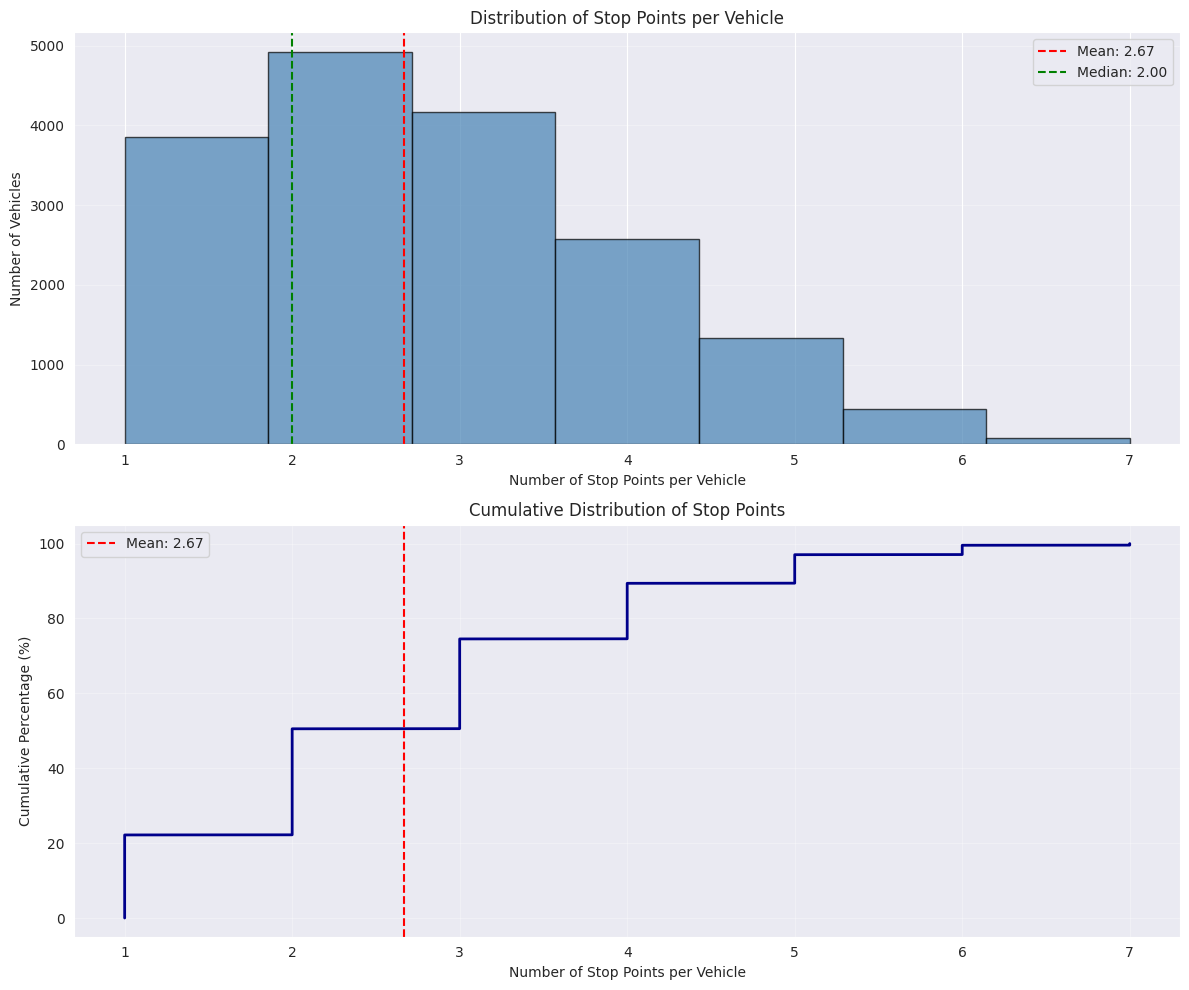


Results saved to: vehicle_stop_points_count.csv
Distribution statistics saved to: stop_points_distribution.txt


Additional Analysis:
  Vehicles with 1 stop point: 3852 (22.19%)
  Vehicles with 2-3 stop points: 9089 (52.35%)
  Vehicles with 4-8 stop points: 4422 (25.47%)
  Vehicles with >8 stop points: 0 (0.00%)


In [72]:

if not private_charges_df.empty:
    # 确定位置列和车辆ID列
    lon_col = None
    lat_col = None
    taxiid_col = None

    for col in private_charges_df.columns:
        if 'pre_lon' in col.lower() or ('lon' in col.lower() and 'pre' in col.lower()):
            lon_col = col
        if 'pre_lat' in col.lower() or ('lat' in col.lower() and 'pre' in col.lower()):
            lat_col = col
        if 'taxiid' in col.lower() or 'taxi_id' in col.lower():
            taxiid_col = col

    if lon_col is None:
        for col in private_charges_df.columns:
            if 'lon' in col.lower():
                lon_col = col
                break
    if lat_col is None:
        for col in private_charges_df.columns:
            if 'lat' in col.lower():
                lat_col = col
                break

    if lon_col is None or lat_col is None or taxiid_col is None:
        print("Error: Cannot find required columns")
        print("Available columns:", list(private_charges_df.columns))
    else:
        print(f"Using columns: {lon_col} (longitude), {lat_col} (latitude), {taxiid_col} (taxiid)")

        # 过滤有效数据
        valid_df = private_charges_df.dropna(subset=[lon_col, lat_col, taxiid_col]).copy()
        valid_df = valid_df[
            (valid_df[lon_col] >= 113) & (valid_df[lon_col] <= 115) &
            (valid_df[lat_col] >= 22) & (valid_df[lat_col] <= 23)
        ]

        if len(valid_df) == 0:
            print("Error: No valid data found")
        else:
            print(f"Processing {len(valid_df)} private charging events from {valid_df[taxiid_col].nunique()} vehicles")

            # ========== 2. 对每辆车进行位置聚类 ==========
            def haversine_distance(lon1, lat1, lon2, lat2):
                """计算两点间的大圆距离（米）"""
                R = 6371000  # 地球半径（米）
                lon1_rad = np.radians(lon1)
                lat1_rad = np.radians(lat1)
                lon2_rad = np.radians(lon2)
                lat2_rad = np.radians(lat2)

                dlon = lon2_rad - lon1_rad
                dlat = lat2_rad - lat1_rad

                a = np.sin(dlat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon/2)**2
                c = 2 * np.arcsin(np.sqrt(a))

                return R * c

            # 自定义距离函数用于DBSCAN（将度转换为米）
            def custom_distance_matrix(coords):
                """计算坐标之间的距离矩阵（米）"""
                n = len(coords)
                distances = np.zeros((n, n))
                for i in range(n):
                    for j in range(i+1, n):
                        dist = haversine_distance(
                            coords[i, 0], coords[i, 1],
                            coords[j, 0], coords[j, 1]
                        )
                        distances[i, j] = dist
                        distances[j, i] = dist
                return distances

            # 对每辆车进行聚类
            vehicle_stop_points = []

            for taxiid, group in valid_df.groupby(taxiid_col):
                coords = group[[lon_col, lat_col]].to_numpy()

                if len(coords) < 2:

                    # 只有一个点，算作1个停留点
                    vehicle_stop_points.append({
                        'taxiid': taxiid,
                        'n_stop_points': 1,
                        'n_events': len(coords)
                    })
                    continue

                # 计算距离矩阵（米）
                dist_matrix = custom_distance_matrix(coords)

                # 使用DBSCAN，eps=200米，min_samples=1（每个点都可以是一个聚类）
                # 注意：DBSCAN需要距离矩阵，我们使用precomputed
                from sklearn.cluster import DBSCAN

                # 由于DBSCAN的precomputed需要对称矩阵，我们直接使用距离矩阵
                dbscan = DBSCAN(eps=500, min_samples=1, metric='precomputed')
                labels = dbscan.fit_predict(dist_matrix)

                # 统计聚类数量（排除噪声点，但这里min_samples=1所以没有噪声）
                n_clusters = len(set(labels))

                vehicle_stop_points.append({
                    'taxiid': taxiid,
                    'n_stop_points': n_clusters,
                    'n_events': len(coords)
                })

            # 转换为DataFrame
            stop_points_df = pd.DataFrame(vehicle_stop_points)

            # ========== 3. 统计分布 ==========
            print("\n" + "=" * 60)
            print("Stop Points Statistics per Vehicle")
            print("=" * 60)

            print(f"\nTotal vehicles: {len(stop_points_df)}")
            print(f"Total private charging events: {stop_points_df['n_events'].sum()}")
            print(f"\nStop Points Distribution:")
            print(f"  Mean: {stop_points_df['n_stop_points'].mean():.2f} points/vehicle")
            print(f"  Median: {stop_points_df['n_stop_points'].median():.2f} points/vehicle")
            print(f"  Min: {stop_points_df['n_stop_points'].min()} points")
            print(f"  Max: {stop_points_df['n_stop_points'].max()} points")
            print(f"  Std: {stop_points_df['n_stop_points'].std():.2f}")

            # 统计不同停留点数量的车辆数
            stop_points_dist = stop_points_df['n_stop_points'].value_counts().sort_index()
            print(f"\nDistribution by number of stop points:")
            print(f"{'Stop Points':<15} {'Vehicles':<15} {'Percentage':<15}")
            print("-" * 45)
            for n_points, count in stop_points_dist.items():
                pct = count / len(stop_points_df) * 100
                print(f"{n_points:<15} {count:<15} {pct:.2f}%")

            # ========== 4. 可视化分布 ==========
            fig, axes = plt.subplots(2, 1, figsize=(12, 10))

            # 4.1 直方图
            axes[0].hist(stop_points_df['n_stop_points'], bins=min(50, stop_points_df['n_stop_points'].max()),
                        edgecolor='black', alpha=0.7, color='steelblue')
            axes[0].axvline(stop_points_df['n_stop_points'].mean(), color='red', linestyle='--',
                           label=f'Mean: {stop_points_df["n_stop_points"].mean():.2f}')
            axes[0].axvline(stop_points_df['n_stop_points'].median(), color='green', linestyle='--',
                           label=f'Median: {stop_points_df["n_stop_points"].median():.2f}')
            axes[0].set_xlabel('Number of Stop Points per Vehicle')
            axes[0].set_ylabel('Number of Vehicles')
            axes[0].set_title('Distribution of Stop Points per Vehicle')
            axes[0].legend()
            axes[0].grid(axis='y', alpha=0.3)

            # 4.2 累积分布
            sorted_points = np.sort(stop_points_df['n_stop_points'])
            cumulative = np.arange(1, len(sorted_points) + 1) / len(sorted_points) * 100
            axes[1].plot(sorted_points, cumulative, linewidth=2, color='darkblue')
            axes[1].axvline(stop_points_df['n_stop_points'].mean(), color='red', linestyle='--',
                           label=f'Mean: {stop_points_df["n_stop_points"].mean():.2f}')
            axes[1].set_xlabel('Number of Stop Points per Vehicle')
            axes[1].set_ylabel('Cumulative Percentage (%)')
            axes[1].set_title('Cumulative Distribution of Stop Points')
            axes[1].grid(True, alpha=0.3)
            axes[1].legend()

            plt.tight_layout()
            plt.show()

            # ========== 5. 保存结果 ==========
            stop_points_df.to_csv('vehicle_stop_points_count.csv', index=False)
            print(f"\nResults saved to: vehicle_stop_points_count.csv")

            # 保存分布统计
            with open('stop_points_distribution.txt', 'w') as f:
                f.write("Stop Points Distribution per Vehicle\n")
                f.write("=" * 60 + "\n\n")
                f.write(f"Total vehicles: {len(stop_points_df)}\n")
                f.write(f"Mean stop points: {stop_points_df['n_stop_points'].mean():.2f}\n")
                f.write(f"Median stop points: {stop_points_df['n_stop_points'].median():.2f}\n")
                f.write(f"Min: {stop_points_df['n_stop_points'].min()}\n")
                f.write(f"Max: {stop_points_df['n_stop_points'].max()}\n\n")
                f.write("Distribution:\n")
                for n_points, count in stop_points_dist.items():
                    pct = count / len(stop_points_df) * 100
                    f.write(f"  {n_points} points: {count} vehicles ({pct:.2f}%)\n")

            print(f"Distribution statistics saved to: stop_points_distribution.txt")

            print("\n" + "=" * 60)

            # ========== 6. 额外分析：停留点数量与事件数的关系 ==========
            print("\nAdditional Analysis:")
            print(f"  Vehicles with 1 stop point: {(stop_points_df['n_stop_points'] == 1).sum()} "
                  f"({(stop_points_df['n_stop_points'] == 1).sum()/len(stop_points_df)*100:.2f}%)")
            print(f"  Vehicles with 2-3 stop points: {((stop_points_df['n_stop_points'] >= 2) & (stop_points_df['n_stop_points'] <= 3)).sum()} "
                  f"({((stop_points_df['n_stop_points'] >= 2) & (stop_points_df['n_stop_points'] <= 3)).sum()/len(stop_points_df)*100:.2f}%)")
            print(f"  Vehicles with 4-8 stop points: {((stop_points_df['n_stop_points'] >= 4) & (stop_points_df['n_stop_points'] <= 8)).sum()} "
                  f"({((stop_points_df['n_stop_points'] >=4) & (stop_points_df['n_stop_points'] <= 8)).sum()/len(stop_points_df)*100:.2f}%)")
            print(f"  Vehicles with >8 stop points: {(stop_points_df['n_stop_points'] > 8).sum()} "
                  f"({(stop_points_df['n_stop_points'] > 8).sum()/len(stop_points_df)*100:.2f}%)")

            print("=" * 60)

In [77]:
# 假设 battery_trace_output 是你包含SOC轨迹的DataFrame

# 1. 找出所有存在 "充电前SOC < 1%" 记录的车辆ID (taxiid)
#    首先，筛选出所有不符合条件的记录
low_soc_events = battery_trace_output[battery_trace_output['SOC_before_pct'] < 0.1]

#    然后，获取这些记录对应的所有唯一的 taxiid
taxiids_to_exclude = low_soc_events['taxiid'].unique()

# 2. 从原始DataFrame中剔除这些车辆的所有记录
#    使用 .isin() 方法来判断每一行的 'taxiid' 是否在我们要排除的列表中
#    前面的 ~ 符号表示 "取反"，即保留那些 taxiid 不在排除列表中的行
filtered_df = battery_trace_output[~battery_trace_output['taxiid'].isin(taxiids_to_exclude)].copy()

# 3. 打印统计信息，验证筛选结果
original_taxi_count = battery_trace_output['taxiid'].nunique()
filtered_taxi_count = filtered_df['taxiid'].nunique()
removed_taxi_count = original_taxi_count - filtered_taxi_count

print("原始DataFrame信息：")
print(f"  总车辆数: {original_taxi_count}")
print(f"  总事件数: {len(battery_trace_output)}")

print(f"\n需要排除的车辆数: {len(taxiids_to_exclude)}")
print(f"  这些车辆是: {taxiids_to_exclude}")

print("\n筛选后DataFrame信息：")
print(f"  剩余车辆数: {filtered_taxi_count}")
print(f"  剩余事件数: {len(filtered_df)}")

print(f"\n共剔除了 {removed_taxi_count} 辆车的所有数据。")

# 新的DataFrame 'filtered_df' 现在可以用于后续分析
# 可以查看一下筛选后的结果
print("\n筛选后的DataFrame示例：")
print(filtered_df.head())

原始DataFrame信息：
  总车辆数: 18226
  总事件数: 395199

需要排除的车辆数: 3845
  这些车辆是: ['UUUB0C2Q3' 'UUUB0C6P9' 'UUUB1C4P3' ... 'UUUBDY1272' 'UUUBDY4242'
 'UUUBDY5702']

筛选后DataFrame信息：
  剩余车辆数: 14381
  剩余事件数: 318107

共剔除了 3845 辆车的所有数据。

筛选后的DataFrame示例：
      taxiid        charge_type  nearest_station_id          start_time  \
0  UUUB0C0M7  dedicated_station                  -1 2020-01-01 04:17:29   
1  UUUB0C0M7  dedicated_station                  -1 2020-01-01 16:18:31   
2  UUUB0C0M7             public                2266 2020-01-02 01:21:09   
3  UUUB0C0M7  dedicated_station                  -1 2020-01-02 04:16:24   
4  UUUB0C0M7  dedicated_station                  -1 2020-01-02 16:09:34   

             end_time  SOC_before_kWh  SOC_after_kWh  SOC_before_pct  \
0 2020-01-01 05:48:13       80.000000      80.000000      100.000000   
1 2020-01-01 17:47:47       47.482698      80.000000       59.353373   
2 2020-01-02 01:35:24       58.004295      59.666795       72.505369   
3 2020-01-02 05:41:39   

In [50]:
filter_ids = filtered_df['taxiid'].unique().tolist()
pickle_path2 = f'output_v3/filter_id.pkl'
with open(pickle_path2, 'wb') as f:  # 注意是 'wb' (write binary)
    # 使用 pickle.dump() 将列表写入文件
    pickle.dump(filter_ids, f)


In [59]:
dedicated_charges_df2=dedicated_charges_df.copy()
for id in taxiids_to_exclude:
    wid = dedicated_charges_df['taxiid']==id
    dedicated_charges_df2=dedicated_charges_df2[~wid]

/tmp/ipykernel_957107/530604616.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dedicated_charges_df2=dedicated_charges_df2[~wid]
/tmp/ipykernel_957107/530604616.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dedicated_charges_df2=dedicated_charges_df2[~wid]
/tmp/ipykernel_957107/530604616.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dedicated_charges_df2=dedicated_charges_df2[~wid]
/tmp/ipykernel_957107/530604616.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dedicated_charges_df2=dedicated_charges_df2[~wid]
/tmp/ipykernel_957107/530604616.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dedicated_charges_df2=dedicated_charges_df2[~wid]
/tmp/ipykernel_957107/530604616.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dedicated_charges_df2=dedicated_charges_df2[~wid]
/tmp

In [60]:
dedicated_charges_df2['taxiid'].nunique()

15037

In [61]:

# ========== 统计专用站充电事件附近是否有公共充电站 ==========

# 1. 加载专用站充电事件

dedicated_charges = dedicated_charges_df2.copy()
# 2. 加载公共充电站数据（应该已经加载了stations_df）

if dedicated_charges.empty:
    logging.warning("专用站充电事件为空")
else:
    # 3. 构建公共充电站的KDTree（如果还没有）
    station_coords = stations_df[['longitude', 'latitude']].to_numpy()
    station_tree = cKDTree(station_coords)

    # 4. Haversine距离计算函数
    def haversine_np(lon1, lat1, lon2, lat2):
        """计算两点间的大圆距离（米）"""
        R = 6371000
        lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
        dlon, dlat = lon2 - lon1, lat2 - lat1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        return R * 2 * np.arcsin(np.sqrt(a))

    # 5. 对每个专用站充电事件的开始点查询最近公共充电站
    start_coords = dedicated_charges[['start_lon', 'start_lat']].to_numpy()

    # 查询最近邻（返回度单位距离）
    distances_deg, station_indices = station_tree.query(start_coords, k=1)

    # 转换为米（粗略转换）
    distances_m_approx = distances_deg * 111320

    # 计算精确距离（米）
    station_coords = stations_df[['longitude', 'latitude']].to_numpy()
    nearest_station_coords = station_coords[station_indices]

    distances_m = haversine_np(
        start_coords[:, 0], start_coords[:, 1],
        nearest_station_coords[:, 0], nearest_station_coords[:, 1]
    )

    # 6. 标记200米内是否有公共充电站
    dedicated_charges['nearest_public_station_dist_m'] = distances_m
    dedicated_charges['nearest_public_station_id'] = stations_df.iloc[station_indices]['station_id'].values
    dedicated_charges['has_nearby_public_station'] = distances_m <= 200

    # 7. 统计结果
    total_events = len(dedicated_charges)
    events_with_nearby = dedicated_charges['has_nearby_public_station'].sum()
    events_without_nearby = total_events - events_with_nearby

    print("\n" + "=" * 60)
    print("专用站充电事件附近公共充电站统计")
    print("=" * 60)
    print(f"总专用站充电事件数: {total_events:,}")
    print(f"  附近200米内有公共充电站: {events_with_nearby:,} ({events_with_nearby/total_events*100:.2f}%)")
    print(f"  附近200米内无公共充电站: {events_without_nearby:,} ({events_without_nearby/total_events*100:.2f}%)")

    # 8. 距离分布统计
    print(f"\n距离最近公共充电站的距离分布:")
    print(f"  平均距离: {dedicated_charges['nearest_public_station_dist_m'].mean():.2f} 米")
    print(f"  中位数距离: {dedicated_charges['nearest_public_station_dist_m'].median():.2f} 米")
    print(f"  最小距离: {dedicated_charges['nearest_public_station_dist_m'].min():.2f} 米")
    print(f"  最大距离: {dedicated_charges['nearest_public_station_dist_m'].max():.2f} 米")

    # 9. 距离分档统计
    print(f"\n距离分档统计:")
    bins = [0, 200, 500, 1000, 2000, float('inf')]
    labels = ['0-200m', '200-500m', '500-1000m', '1000-2000m', '>2000m']
    dedicated_charges['distance_bin'] = pd.cut(
        dedicated_charges['nearest_public_station_dist_m'],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    distance_dist = dedicated_charges['distance_bin'].value_counts().sort_index()
    for bin_name, count in distance_dist.items():
        print(f"  {bin_name}: {count:,} ({count/total_events*100:.2f}%)")

    # 10. 显示示例数据
    print(f"\n专用站充电事件示例（前10条）：")
    display_cols = ['taxiid', 'start_time', 'start_lon', 'start_lat',
                    'nearest_public_station_id', 'nearest_public_station_dist_m',
                    'has_nearby_public_station']
    print(dedicated_charges[display_cols].head(10))

    print("=" * 60)


专用站充电事件附近公共充电站统计
总专用站充电事件数: 202,211
  附近200米内有公共充电站: 64,954 (32.12%)
  附近200米内无公共充电站: 137,257 (67.88%)

距离最近公共充电站的距离分布:
  平均距离: 2882.19 米
  中位数距离: 311.49 米
  最小距离: 0.73 米
  最大距离: 5533421.98 米

距离分档统计:
  0-200m: 64,954 (32.12%)
  200-500m: 70,706 (34.97%)
  500-1000m: 47,303 (23.39%)
  1000-2000m: 16,042 (7.93%)
  >2000m: 3,206 (1.59%)

专用站充电事件示例（前10条）：
      taxiid          start_time   start_lon  start_lat  \
0  UUUB0C0M7 2020-01-01 04:17:29  114.143974  22.557758   
1  UUUB0C0M7 2020-01-01 16:18:31  114.143753  22.557638   
2  UUUB0C0M7 2020-01-02 04:16:24  114.143974  22.557781   
3  UUUB0C0M7 2020-01-02 16:09:34  114.143990  22.557774   
4  UUUB0C0M7 2020-01-03 04:33:40  114.143890  22.557579   
5  UUUB0C0M7 2020-01-03 16:01:51  114.143898  22.557587   
6  UUUB0C0M7 2020-01-04 05:04:38  114.143761  22.557646   
7  UUUB0C0M7 2020-01-04 16:20:01  114.143723  22.557545   
8  UUUB0C0M7 2020-01-05 05:03:00  114.143776  22.557251   
9  UUUB0C0M7 2020-01-06 03:23:20  114.143967  22.55774

In [64]:
dedicated_charges[dedicated_charges['nearest_public_station_dist_m']<=200]['taxiid'].nunique()

10471

In [76]:
battery_trace_output[battery_trace_output['SOC_before_kWh']<1]

,taxiid,charge_type,nearest_station_id,start_time,end_time,SOC_before_kWh,SOC_after_kWh,SOC_before_pct,SOC_after_pct,energy_used_kWh,energy_in_kWh,distance_km,drive_s,idle_s,gap_s,missing_s,charge_dur,wait_dur,giveup
251,UUUB0C2Q3,dedicated_station,-1,2020-01-03 06:27:56,2020-01-03 07:58:19,0.0,64.774722,0.0,80.968403,6.780327,64.774722,45.202182,3911.0,3291.0,7202.0,0.0,5423.0,0.0,False
955,UUUB0C6P9,public,2131,2020-01-03 00:29:02,2020-01-03 00:44:07,0.0,1.759722,0.0,2.199653,19.095828,1.759722,127.305521,15196.0,9810.0,25006.0,2268.0,905.0,0.0,False
956,UUUB0C6P9,public,2148,2020-01-03 02:48:15,2020-01-03 03:07:21,0.0,1.806389,0.0,2.257986,2.786556,1.806389,18.577038,1774.0,1979.0,3753.0,3695.0,929.0,217.0,False
957,UUUB0C6P9,public,2148,2020-01-03 03:50:33,2020-01-03 04:00:48,0.0,1.195833,0.0,1.494792,2.363742,1.195833,15.758279,1626.0,966.0,2592.0,0.0,615.0,0.0,False
958,UUUB0C6P9,public,2377,2020-01-03 07:10:01,2020-01-03 07:20:01,0.0,0.583333,0.0,0.729167,8.911578,0.583333,59.410519,4772.0,5127.0,9899.0,612.0,600.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394992,UUUBDY4242,dedicated_station,-1,2020-01-05 11:07:20,2020-01-05 12:27:29,0.0,57.440833,0.0,71.801042,11.217695,57.440833,74.784633,8746.0,6232.0,14978.0,0.0,4809.0,0.0,False
395025,UUUBDY5702,public,1269,2020-01-05 20:44:21,2020-01-05 20:57:47,0.0,13.433333,0.0,16.791667,85.582897,13.433333,570.552647,65874.0,51946.0,117820.0,12954.0,806.0,0.0,False
395026,UUUBDY5702,public,1399,2020-01-06 15:20:39,2020-01-06 15:30:49,0.0,0.593056,0.0,0.741319,51.228676,0.593056,341.524507,36018.0,20257.0,56275.0,7867.0,610.0,0.0,False
395027,UUUBDY5702,public,1217,2020-01-06 20:43:47,2020-01-06 20:57:17,0.0,0.787500,0.0,0.984375,13.059010,0.787500,87.060069,10728.0,7387.0,18115.0,653.0,810.0,0.0,False


In [48]:
filtered_df[1000:1100]

,taxiid,charge_type,nearest_station_id,start_time,end_time,SOC_before_kWh,SOC_after_kWh,SOC_before_pct,SOC_after_pct,energy_used_kWh,energy_in_kWh,distance_km,drive_s,idle_s,gap_s,missing_s,charge_dur,wait_dur,giveup
1050,UUUB0C7M5,dedicated_station,-1,2020-01-03 05:34:16,2020-01-03 06:49:51,43.628960,80.0,54.536200,100.0,36.371040,36.371040,242.473601,24378.0,13242.0,37620.0,6075.0,4535.0,0.0,False
1051,UUUB0C7M5,dedicated_station,-1,2020-01-04 04:51:27,2020-01-04 06:12:13,36.058045,80.0,45.072556,100.0,43.941955,43.941955,292.946367,35842.0,25833.0,61675.0,13837.0,4846.0,0.0,False
1052,UUUB0C7M5,dedicated_station,-1,2020-01-04 06:50:31,2020-01-04 14:36:37,79.374801,80.0,99.218501,100.0,0.625199,0.625199,4.167994,321.0,879.0,1200.0,1098.0,27966.0,0.0,False
1053,UUUB0C7M5,dedicated_station,-1,2020-01-05 02:02:36,2020-01-05 03:27:32,53.981024,80.0,67.476280,100.0,26.018976,26.018976,173.459840,19588.0,13144.0,32732.0,6753.0,5096.0,0.0,False
1054,UUUB0C7M5,dedicated_station,-1,2020-01-05 05:15:37,2020-01-05 06:53:09,73.332150,80.0,91.665188,100.0,6.667850,6.667850,44.452332,4352.0,1090.0,5442.0,0.0,5852.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1145,UUUB0C7N5,dedicated_station,-1,2020-01-04 05:57:03,2020-01-04 14:42:11,80.000000,80.0,100.000000,100.0,0.000000,0.000000,0.000000,0.0,346.0,346.0,0.0,31508.0,0.0,False
1146,UUUB0C7N5,public,1788,2020-01-04 14:42:11,2020-01-04 14:53:26,80.000000,80.0,100.000000,100.0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,675.0,0.0,False
1147,UUUB0C7N5,dedicated_station,-1,2020-01-04 20:23:29,2020-01-05 14:40:23,63.627128,80.0,79.533910,100.0,16.372872,16.372872,109.152480,10823.0,8209.0,19032.0,734.0,65814.0,0.0,False
1148,UUUB0C7N5,dedicated_station,-1,2020-01-05 19:55:23,2020-01-05 22:54:43,63.199224,80.0,78.999030,100.0,16.800776,16.800776,112.005175,11941.0,6474.0,18415.0,0.0,10760.0,0.0,False


In [45]:
all_charging_events[all_charging_events['taxiid']=='UUUBDZ1042']

,taxiid,nearest_station_id,start_time,end_time,duration_s,stay_lon,stay_lat,charge_type


In [18]:
all_public_charges[all_public_charges['taxiid']=='UUUBDZ1042'][5:15]

,taxiid,nearest_station_id,start_time,end_time,duration_s,stay_lon,stay_lat,charge_type
363338,UUUBDZ1042,1645,2020-01-02 04:32:23,2020-01-02 04:53:22,1259.0,114.021172,22.536577,public
363339,UUUBDZ1042,1616,2020-01-02 05:31:40,2020-01-02 05:48:16,996.0,114.013672,22.543766,public
363340,UUUBDZ1042,1597,2020-01-02 06:36:17,2020-01-02 06:55:45,1168.0,114.002590,22.537086,public
363341,UUUBDZ1042,1821,2020-01-02 08:39:26,2020-01-02 08:50:03,637.0,114.047092,22.545160,public
363342,UUUBDZ1042,1923,2020-01-02 10:55:51,2020-01-02 11:18:13,1342.0,114.062057,22.518675,public
363343,UUUBDZ1042,1816,2020-01-02 12:07:43,2020-01-02 12:46:23,2320.0,114.045757,22.594401,public
363344,UUUBDZ1042,1597,2020-01-03 05:10:16,2020-01-03 07:00:35,6619.0,114.002705,22.537162,public
363345,UUUBDZ1042,1654,2020-01-03 13:00:17,2020-01-03 13:18:13,1076.0,114.021614,22.529974,public
363346,UUUBDZ1042,1657,2020-01-03 19:53:31,2020-01-03 20:03:31,600.0,114.021172,22.540981,public
363347,UUUBDZ1042,1597,2020-01-04 06:32:18,2020-01-04 07:02:27,1809.0,114.002640,22.537053,public


In [22]:
charging_events[charging_events['taxiid']=='UUUBDZ1042'][2:]

,taxiid,nearest_station_id,start_time,end_time,duration_s,stay_lon,stay_lat,num_points,charge_type
186044,UUUBDZ1042,1923,2020-01-01 10:29:59,2020-01-01 10:48:15,1096.0,114.062057,22.518589,46,public
186045,UUUBDZ1042,1645,2020-01-02 04:32:23,2020-01-02 04:53:22,1259.0,114.021172,22.536577,71,public
186046,UUUBDZ1042,1616,2020-01-02 05:31:40,2020-01-02 05:48:16,996.0,114.013672,22.543766,55,public
186047,UUUBDZ1042,1923,2020-01-02 10:55:51,2020-01-02 11:18:13,1342.0,114.062057,22.518675,53,public
186048,UUUBDZ1042,1654,2020-01-03 13:00:17,2020-01-03 13:18:13,1076.0,114.021614,22.529974,37,public
186049,UUUBDZ1042,1657,2020-01-03 19:53:31,2020-01-03 20:03:31,600.0,114.021172,22.540981,18,public
186050,UUUBDZ1042,2140,2020-01-04 07:43:14,2020-01-04 07:58:14,900.0,114.112587,22.543743,32,public
186051,UUUBDZ1042,2272,2020-01-04 12:19:04,2020-01-04 13:08:35,2971.0,114.130363,22.559555,114,public
186052,UUUBDZ1042,1874,2020-01-05 08:20:52,2020-01-05 08:35:12,860.0,114.056564,22.525894,32,public
186053,UUUBDZ1042,1923,2020-01-05 08:52:32,2020-01-05 09:33:22,2450.0,114.062149,22.518671,78,public


## 7. 统计分析和可视化

### 7.1 基本统计指标


Charging Event Start Time Distribution (by Type)
      Public_Charging  Private_Charging   Total
hour                                           
0              153.72             62.31  216.03
1              234.40            100.33  334.73
2              257.42            153.17  410.59
3              246.92            194.06  440.98
4              226.65            200.68  427.33
5              211.39            165.74  377.13
6              194.12             98.17  292.29
7              141.78             54.75  196.53
8               81.71             35.13  116.84
9               89.90             29.98  119.88
10             124.00             30.19  154.19
11             175.14             45.81  220.95
12             204.76             63.30  268.06
13             149.06             51.06  200.12
14             104.32             49.72  154.04
15             114.02             75.57  189.59
16             145.56            123.19  268.75
17             150.12            110.08

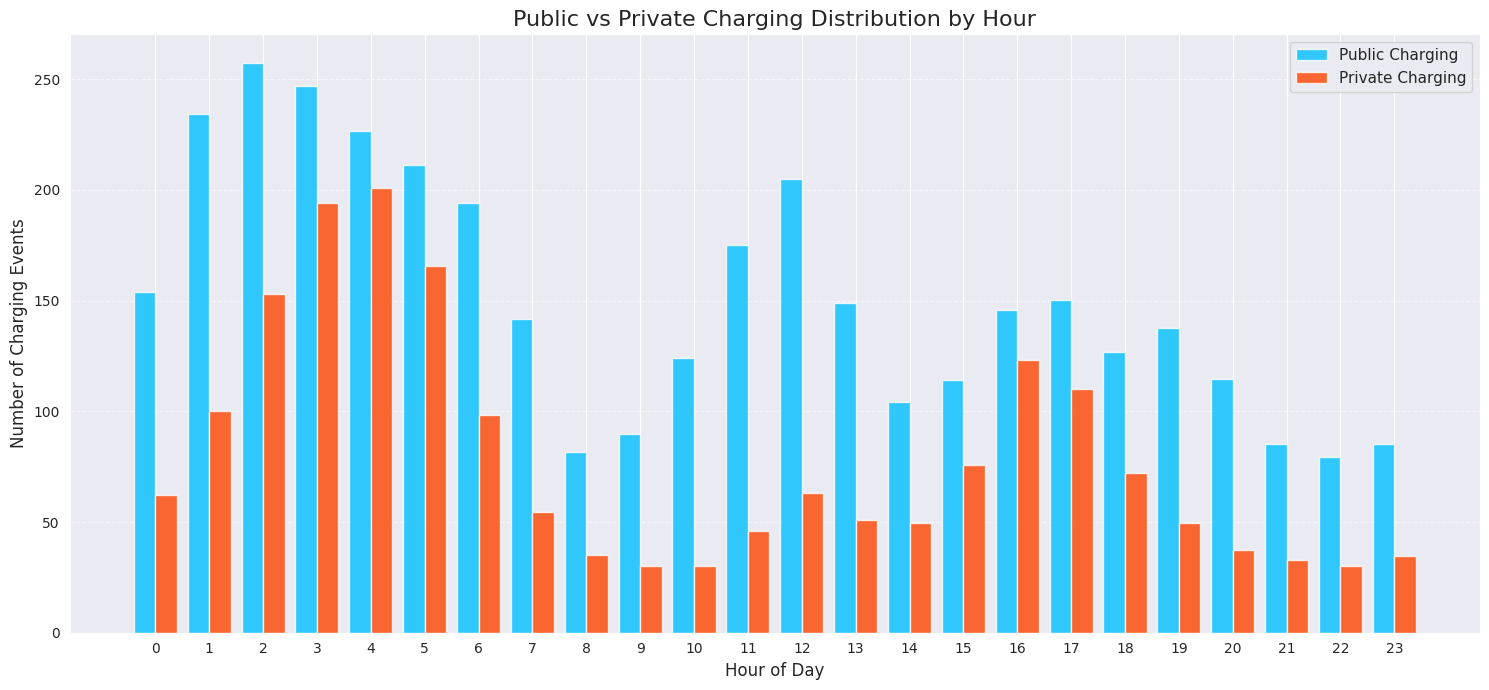

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ========== Charging Distribution by Hour (Public vs Private) ==========

# Determine which DataFrame to use
if 'all_charging_events' in locals() or 'all_charging_events' in globals():
    df = all_charging_events.copy()
elif 'battery_trace_output' in locals() or 'battery_trace_output' in globals():
    df = battery_trace_output.copy()
elif os.path.exists(BATTERY_TRACE_FILE):
    df = pd.read_parquet(BATTERY_TRACE_FILE)
else:
    logging.warning("Charging event data not found")
    df = pd.DataFrame()

if not df.empty and 'start_time' in df.columns and 'charge_type' in df.columns:
    # 1. Extract hour and separate by type
    df['hour'] = df['start_time'].dt.hour
    public_charges = df[df['charge_type'] == 'public']
    private_charges = df[df['charge_type'] == 'private_gap']

    # 2. Count events per hour, ensuring all 24 hours exist (fill missing with 0)
    public_counts = public_charges['hour'].value_counts().reindex(range(24), fill_value=0).sort_index()
    private_counts = private_charges['hour'].value_counts().reindex(range(24), fill_value=0).sort_index()

    # 3. Print data
    print("=" * 60)
    print("Charging Event Start Time Distribution (by Type)")
    print("=" * 60)
    distribution_df = pd.DataFrame({
        'Public_Charging': public_counts/100,
        'Private_Charging': private_counts/100
    })
    distribution_df['Total'] = distribution_df['Public_Charging'] + distribution_df['Private_Charging']
    print(distribution_df.to_string())

    # 4. Visualization: grouped bar chart
    plt.figure(figsize=(15, 7))

    x = np.arange(24)  # Hour positions
    width = 0.4        # Bar width

    # Draw grouped bars
    plt.bar(x - width/2, public_counts/100, width, label='Public Charging', color='deepskyblue', alpha=0.8)
    plt.bar(x + width/2, private_counts/100, width, label='Private Charging', color='orangered', alpha=0.8)

    # Add title, labels, and legend
    plt.ylabel('Number of Charging Events', fontsize=12)
    plt.xlabel('Hour of Day', fontsize=12)
    plt.title('Public vs Private Charging Distribution by Hour', fontsize=16)
    plt.xticks(x)
    plt.legend(fontsize=11)

    # Add Y-axis grid
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # Format Y-axis with thousand separators
    ax = plt.gca()
    #ax.get_yaxis().set_major_formatter(mticker.FuncFormatter(lambda val, p: format(int(val), ',')))

    plt.tight_layout()
    plt.show()

else:
    print("Data is empty or missing 'start_time' or 'charge_type' columns")

Public Charging Statistics

1. Average Charging Frequency per Vehicle per Day:
   Total vehicles: 18060
   Mean: 1.92 times/day
   Median: 1.67 times/day
   Min: 1.00 times/day
   Max: 9.71 times/day
   Std: 0.93 times/day

2. Charging Duration Distribution (at station):
   Total events: 172000
   Mean: 23.26 minutes
   Median: 17.50 minutes
   Min: 10.00 minutes
   Max: 730.50 minutes
   Std: 23.18 minutes
   10th percentile: 10.92 minutes
   25th percentile: 12.75 minutes
   75th percentile: 24.58 minutes
   95th percentile: 53.75 minutes

3. Waiting Time Distribution:
   Total events: 172000
   Events with wait > 0: 61775 (35.92%)
   Mean (all): 5.99 minutes
   Mean (wait > 0): 16.68 minutes
   Median: 0.00 minutes
   Max: 599.03 minutes
   5th percentile: 0.00 minutes
   75th percentile: 8.55 minutes
   90th percentile: 19.05 minutes
   95th percentile: 27.28 minutes


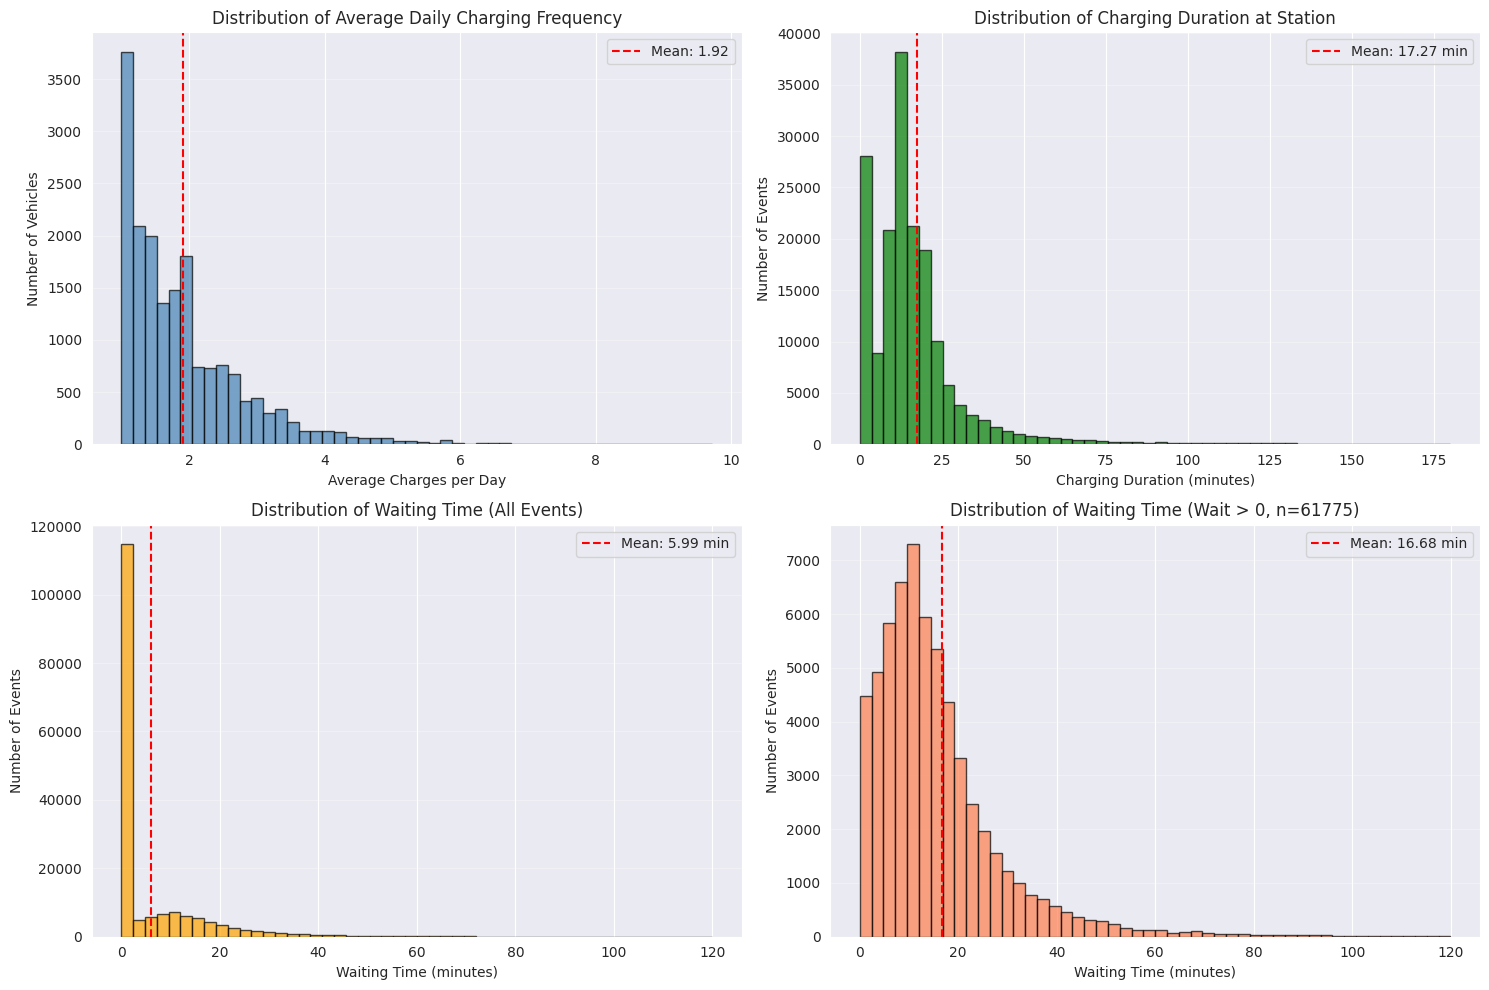

In [49]:

# ========== 读取数据 ==========
char_queue_file = CHAR_QUEUE_FILE  # 根据实际路径调整
if os.path.exists(char_queue_file):
    cq_df = pd.read_parquet(char_queue_file)
else:
    # 尝试其他可能的路径
    if os.path.exists(CHAR_QUEUE_FILE):
        cq_df = pd.read_parquet(CHAR_QUEUE_FILE)
    else:
        print(f"Error: Cannot find char_queue.parquet file")
        cq_df = pd.DataFrame()

if not cq_df.empty:
    # 确保时间列是datetime类型
    if 'arrive_time' in cq_df.columns:
        cq_df['arrive_time'] = pd.to_datetime(cq_df['arrive_time'])
        cq_df['date'] = cq_df['arrive_time'].dt.date

    print("=" * 60)
    print("Public Charging Statistics")
    print("=" * 60)

    # 1. 每车每日平均充电次数
    if 'taxiid' in cq_df.columns and 'date' in cq_df.columns:
        daily_charges = cq_df.groupby(['taxiid', 'date']).size().reset_index(name='charges_per_day')
        avg_charges_per_day = daily_charges.groupby('taxiid')['charges_per_day'].mean()

        print(f"\n1. Average Charging Frequency per Vehicle per Day:")
        print(f"   Total vehicles: {len(avg_charges_per_day)}")
        print(f"   Mean: {avg_charges_per_day.mean():.2f} times/day")
        print(f"   Median: {avg_charges_per_day.median():.2f} times/day")
        print(f"   Min: {avg_charges_per_day.min():.2f} times/day")
        print(f"   Max: {avg_charges_per_day.max():.2f} times/day")
        print(f"   Std: {avg_charges_per_day.std():.2f} times/day")

    # 2. 在站停留时间分布（charge_dur）
    if 'charge_dur' in cq_df.columns:
        # 转换为分钟
        charge_dur_minutes = (cq_df['charge_dur'] + cq_df['wait_dur'])/ 60

        print(f"\n2. Charging Duration Distribution (at station):")
        print(f"   Total events: {len(charge_dur_minutes)}")
        print(f"   Mean: {charge_dur_minutes.mean():.2f} minutes")
        print(f"   Median: {charge_dur_minutes.median():.2f} minutes")
        print(f"   Min: {charge_dur_minutes.min():.2f} minutes")
        print(f"   Max: {charge_dur_minutes.max():.2f} minutes")
        print(f"   Std: {charge_dur_minutes.std():.2f} minutes")
        print(f"   10th percentile: {charge_dur_minutes.quantile(0.10):.2f} minutes")
        print(f"   25th percentile: {charge_dur_minutes.quantile(0.25):.2f} minutes")
        print(f"   75th percentile: {charge_dur_minutes.quantile(0.75):.2f} minutes")
        print(f"   95th percentile: {charge_dur_minutes.quantile(0.95):.2f} minutes")

    # 3. 等待时间分布（wait_dur）
    if 'wait_dur' in cq_df.columns:
        # 转换为分钟
        wait_dur_minutes = cq_df['wait_dur'] / 60

        print(f"\n3. Waiting Time Distribution:")
        print(f"   Total events: {len(wait_dur_minutes)}")
        print(f"   Events with wait > 0: {(wait_dur_minutes > 0).sum()} ({(wait_dur_minutes > 0).sum()/len(wait_dur_minutes)*100:.2f}%)")
        print(f"   Mean (all): {wait_dur_minutes.mean():.2f} minutes")
        print(f"   Mean (wait > 0): {wait_dur_minutes[wait_dur_minutes > 0].mean():.2f} minutes" if (wait_dur_minutes > 0).sum() > 0 else "   Mean (wait > 0): N/A")
        print(f"   Median: {wait_dur_minutes.median():.2f} minutes")
        print(f"   Max: {wait_dur_minutes.max():.2f} minutes")
        print(f"   5th percentile: {wait_dur_minutes.quantile(0.05):.2f} minutes")
        print(f"   75th percentile: {wait_dur_minutes.quantile(0.75):.2f} minutes")
        print(f"   90th percentile: {wait_dur_minutes.quantile(0.90):.2f} minutes")
        print(f"   95th percentile: {wait_dur_minutes.quantile(0.95):.2f} minutes")

    # 4. 可视化
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 4.1 每车每日平均充电次数分布
    if 'taxiid' in cq_df.columns and 'date' in cq_df.columns:
        axes[0, 0].hist(avg_charges_per_day.values, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
        axes[0, 0].set_xlabel('Average Charges per Day')
        axes[0, 0].set_ylabel('Number of Vehicles')
        axes[0, 0].set_title('Distribution of Average Daily Charging Frequency')
        axes[0, 0].grid(axis='y', alpha=0.3)
        axes[0, 0].axvline(avg_charges_per_day.mean(), color='red', linestyle='--', label=f'Mean: {avg_charges_per_day.mean():.2f}')
        axes[0, 0].legend()

    # 4.2 充电时长分布
    if 'charge_dur' in cq_df.columns:
        charge_dur_minutes = cq_df['charge_dur'] / 60
        # 限制显示范围到合理值（例如0-180分钟）
        charge_dur_filtered = charge_dur_minutes[charge_dur_minutes <= 180]
        axes[0, 1].hist(charge_dur_filtered.values, bins=50, color='green', alpha=0.7, edgecolor='black')
        axes[0, 1].set_xlabel('Charging Duration (minutes)')
        axes[0, 1].set_ylabel('Number of Events')
        axes[0, 1].set_title('Distribution of Charging Duration at Station')
        axes[0, 1].grid(axis='y', alpha=0.3)
        axes[0, 1].axvline(charge_dur_minutes.mean(), color='red', linestyle='--', label=f'Mean: {charge_dur_minutes.mean():.2f} min')
        axes[0, 1].legend()

    # 4.3 等待时间分布（所有事件）
    if 'wait_dur' in cq_df.columns:
        wait_dur_minutes = cq_df['wait_dur'] / 60
        # 限制显示范围（例如0-120分钟）
        wait_dur_filtered = wait_dur_minutes[wait_dur_minutes <= 120]
        axes[1, 0].hist(wait_dur_filtered.values, bins=50, color='orange', alpha=0.7, edgecolor='black')
        axes[1, 0].set_xlabel('Waiting Time (minutes)')
        axes[1, 0].set_ylabel('Number of Events')
        axes[1, 0].set_title('Distribution of Waiting Time (All Events)')
        axes[1, 0].grid(axis='y', alpha=0.3)
        axes[1, 0].axvline(wait_dur_minutes.mean(), color='red', linestyle='--', label=f'Mean: {wait_dur_minutes.mean():.2f} min')
        axes[1, 0].legend()

    # 4.4 等待时间分布（仅等待时间>0的事件）
    if 'wait_dur' in cq_df.columns:
        wait_dur_minutes = cq_df['wait_dur'] / 60
        wait_positive = wait_dur_minutes[wait_dur_minutes > 0]
        if len(wait_positive) > 0:
            wait_positive_filtered = wait_positive[wait_positive <= 120]
            axes[1, 1].hist(wait_positive_filtered.values, bins=50, color='coral', alpha=0.7, edgecolor='black')
            axes[1, 1].set_xlabel('Waiting Time (minutes)')
            axes[1, 1].set_ylabel('Number of Events')
            axes[1, 1].set_title(f'Distribution of Waiting Time (Wait > 0, n={len(wait_positive)})')
            axes[1, 1].grid(axis='y', alpha=0.3)
            axes[1, 1].axvline(wait_positive.mean(), color='red', linestyle='--', label=f'Mean: {wait_positive.mean():.2f} min')
            axes[1, 1].legend()
        else:
            axes[1, 1].text(0.5, 0.5, 'No events with wait > 0', ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('Distribution of Waiting Time (Wait > 0)')

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 60)

else:
    print("Error: char_queue DataFrame is empty or file not found")

In [68]:
# 基本统计
if 'char_queue_df' in locals() and not char_queue_df.empty:
    print("=" * 60)
    print("排队和充电统计")
    print("=" * 60)

    print(f"\n总充电事件数: {len(char_queue_df):,}")
    print(f"涉及车辆数: {char_queue_df['taxiid'].nunique():,}")
    print(f"涉及充电站数: {char_queue_df['nearest_station_id'].nunique():,}")

    print(f"\n平均等待时间: {char_queue_df['wait_dur'].mean():.2f} 秒 ({char_queue_df['wait_dur'].mean()/60:.2f} 分钟)")
    print(f"中位数等待时间: {char_queue_df['wait_dur'].median():.2f} 秒 ({char_queue_df['wait_dur'].median()/60:.2f} 分钟)")
    print(f"95%分位数等待时间: {char_queue_df['wait_dur'].quantile(0.95):.2f} 秒 ({char_queue_df['wait_dur'].quantile(0.95)/60:.2f} 分钟)")

    print(f"\n放弃率: {char_queue_df['giveup'].mean():.2%}")
    print(f"放弃事件数: {char_queue_df['giveup'].sum():,}")

    successful_charges = char_queue_df[char_queue_df['giveup'] == False]
    if not successful_charges.empty:
        print(f"\n成功充电事件数: {len(successful_charges):,}")
        print(f"平均充电时长: {successful_charges['charge_dur'].mean()/60:.2f} 分钟")
        print(f"中位数充电时长: {successful_charges['charge_dur'].median()/60:.2f} 分钟")

    print("=" * 60)


排队和充电统计

总充电事件数: 363,429
涉及车辆数: 19,467
涉及充电站数: 1,194

平均等待时间: 6741.49 秒 (112.36 分钟)
中位数等待时间: 590.00 秒 (9.83 分钟)
95%分位数等待时间: 38035.20 秒 (633.92 分钟)

放弃率: 34.74%
放弃事件数: 126,270

成功充电事件数: 237,159
平均充电时长: 45.75 分钟
中位数充电时长: 17.18 分钟


In [69]:
# 每日充电次数统计
if 'char_queue_df' in locals() and not char_queue_df.empty:
    char_queue_df['charge_date'] = char_queue_df['arrive_time'].dt.date

    # 每辆车每天的成功充电次数
    daily_charges = char_queue_df[char_queue_df['giveup'] == False].groupby(['taxiid', 'charge_date']).size().reset_index(name='daily_charge_count')

    # 每辆车的平均每日充电次数
    avg_daily_per_taxi = daily_charges.groupby('taxiid')['daily_charge_count'].mean().reset_index(name='avg_daily_charges')

    overall_avg = avg_daily_per_taxi['avg_daily_charges'].mean()

    print(f"\n平均每日充电次数（每车）: {overall_avg:.2f} 次/天")
    print(f"中位数每日充电次数: {avg_daily_per_taxi['avg_daily_charges'].median():.2f} 次/天")



平均每日充电次数（每车）: 2.18 次/天
中位数每日充电次数: 2.00 次/天


In [ ]:
# SOC统计
if os.path.exists(BATTERY_TRACE_FILE):
    battery_trace = pd.read_parquet(BATTERY_TRACE_FILE)

    print("\n" + "=" * 60)
    print("SOC统计")
    print("=" * 60)

    print(f"\n充电前SOC统计:")
    print(f"  平均: {battery_trace['SOC_before_pct'].mean():.2f}%")
    print(f"  中位数: {battery_trace['SOC_before_pct'].median():.2f}%")
    print(f"  最小值: {battery_trace['SOC_before_pct'].min():.2f}%")

    low_soc = (battery_trace['SOC_before_pct'] < 20).sum()
    print(f"\n低电量充电次数 (SOC < 20%): {low_soc:,} ({low_soc/len(battery_trace)*100:.2f}%)")

    print(f"\n充电后SOC统计:")
    print(f"  平均: {battery_trace['SOC_after_pct'].mean():.2f}%")
    print(f"  中位数: {battery_trace['SOC_after_pct'].median():.2f}%")
    print(f"  最大值: {battery_trace['SOC_after_pct'].max():.2f}%")

    print("=" * 60)


### 7.2 可视化


In [ ]:
# 等待时间分布
if 'char_queue_df' in locals() and not char_queue_df.empty:
    waiting_events = char_queue_df[char_queue_df['wait_dur'] > 0.1]  # 只显示有等待的

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 等待时间直方图
    axes[0].hist(waiting_events['wait_dur'] / 60, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('等待时间 (分钟)')
    axes[0].set_ylabel('事件数')
    axes[0].set_title('等待时间分布')
    axes[0].set_xlim(0, 120)  # 最多显示2小时

    # 总停留时长分布
    char_queue_df['stay_duration_min'] = (
        (char_queue_df['leave_time'] - char_queue_df['arrive_time']).dt.total_seconds() / 60
    )
    axes[1].hist(char_queue_df['stay_duration_min'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('总停留时长 (分钟)')
    axes[1].set_ylabel('事件数')
    axes[1].set_title('总停留时长分布')
    axes[1].set_xlim(0, 180)  # 最多显示3小时

    plt.tight_layout()
    plt.show()


In [ ]:
# SOC分布
if os.path.exists(BATTERY_TRACE_FILE):
    battery_trace = pd.read_parquet(BATTERY_TRACE_FILE)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 充电前SOC分布
    axes[0].hist(battery_trace['SOC_before_pct'], bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[0].set_xlabel('SOC (%)')
    axes[0].set_ylabel('事件数')
    axes[0].set_title('充电前SOC分布')
    axes[0].axvline(20, color='red', linestyle='--', label='20% 低电量线')
    axes[0].legend()

    # 充电后SOC分布
    axes[1].hist(battery_trace['SOC_after_pct'], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[1].set_xlabel('SOC (%)')
    axes[1].set_ylabel('事件数')
    axes[1].set_title('充电后SOC分布')

    plt.tight_layout()
    plt.show()


In [ ]:
# 两次充电间距离分布
if os.path.exists(ENERGY_GAP_FILE):
    energy_gap_df = pd.read_parquet(ENERGY_GAP_FILE)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 距离分布
    axes[0].hist(energy_gap_df['distance_km'], bins=50, edgecolor='black', alpha=0.7, color='purple')
    axes[0].set_xlabel('距离 (km)')
    axes[0].set_ylabel('事件数')
    axes[0].set_title('两次充电间行驶距离分布')

    # 能耗分布
    axes[1].hist(energy_gap_df['energy_used_kWh'], bins=50, edgecolor='black', alpha=0.7, color='brown')
    axes[1].set_xlabel('能耗 (kWh)')
    axes[1].set_ylabel('事件数')
    axes[1].set_title('两次充电间能耗分布')

    plt.tight_layout()
    plt.show()


In [ ]:
# 充电事件空间分布地图
if 'charging_events' in locals() and not charging_events.empty:
    # 计算地图中心
    center_lat = charging_events['stay_lat'].mean()
    center_lon = charging_events['stay_lon'].mean()

    # 创建地图
    m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles='OpenStreetMap')

    # 添加充电站
    station_cluster = MarkerCluster(name='Charging Stations').add_to(m)
    for _, row in stations_df.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=5,
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6,
            popup=f"Station {row['station_id']}<br>Piles: {row['num_piles']}"
        ).add_to(station_cluster)

    # 添加充电事件（采样显示，避免过多）
    sample_size = min(1000, len(charging_events))
    charge_sample = charging_events.sample(n=sample_size) if len(charging_events) > sample_size else charging_events

    charge_cluster = MarkerCluster(name='Charging Events').add_to(m)
    for _, row in charge_sample.iterrows():
        folium.CircleMarker(
            location=[row['stay_lat'], row['stay_lon']],
            radius=3,
            color='red',
            fill=True,
            fill_color='red',
            fill_opacity=0.4,
            popup=f"Taxi: {row['taxiid']}<br>Duration: {row['duration_s']/60:.1f} min"
        ).add_to(charge_cluster)

    folium.LayerControl().add_to(m)
    m


## 8. 单车辆案例分析

可以在这里选择特定车辆进行详细分析


In [ ]:
# 选择一个车辆进行详细分析
TID = 'UUUB0C0M7'  # 可以改成任意车辆ID

if 'charging_events' in locals():
    ce_tid = charging_events[charging_events['taxiid'] == TID].sort_values('start_time')

    if not ce_tid.empty:
        print(f"车辆 {TID} 的充电事件:")
        print(f"总充电次数: {len(ce_tid)}")
        print(ce_tid[['start_time', 'end_time', 'duration_s', 'nearest_station_id']])

        if os.path.exists(BATTERY_TRACE_FILE):
            battery_trace_tid = pd.read_parquet(BATTERY_TRACE_FILE)
            battery_trace_tid = battery_trace_tid[battery_trace_tid['taxiid'] == TID].sort_values('start_time')

            if not battery_trace_tid.empty:
                print(f"\nSOC轨迹:")
                print(battery_trace_tid[['start_time', 'SOC_before_pct', 'SOC_after_pct',
                                         'energy_used_kWh', 'energy_in_kWh']])
    else:
        print(f"车辆 {TID} 没有充电事件")
else:
    print("请先加载充电事件数据")
